In [1]:
# rs booked_flights_metro

In [2]:
# ------------------------------------------------------------
# LOAD df_bookings + icao_cluster.csv (FIXED)
# ------------------------------------------------------------

import pandas as pd
import gcsfs
import zipfile

# 1. Load df_bookings from ZIP (WORKING)
url_zip = "gs://agntworks-data-dev/wheelsup/raw/AgntWorks.zip"
fs = gcsfs.GCSFileSystem()

with fs.open(url_zip.replace('gs://', '')) as f:
    zf = zipfile.ZipFile(f)
    df_bookings = pd.read_csv(zf.open('AgntWorks/booked_flights.csv'), low_memory=False)

# 2. Load icao_cluster.csv via GCS (SAME AUTH)
url_icao = "gs://agntworks-data-dev/wheelsup/processed/transformed_icao_metro.csv"
df_icao = pd.read_csv(fs.open(url_icao.replace('gs://', '')))

print(f"✅ df_bookings: {df_bookings.shape}")
print(f"✅ df_icao:    {df_icao.shape}")
print(f"\nMemory: {df_bookings.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\ndf_bookings preview:")
print(df_bookings.head(2))
print("\ndf_icao preview:")
print(df_icao.head(2))

✅ df_bookings: (258370, 43)
✅ df_icao:    (16002, 2)

Memory: 447.9 MB

df_bookings preview:
   flightId  atlasreservationid flightStatus  legOrder  flightoriginAirportId  \
0   1208327              794518    Cancelled         1                    810   
1   1208330              794521        Flown         1                    333   

  flightoriginAirport   flightoriginAirportName flightoriginAirportCity  \
0                KTEB                 Teterboro               Teterboro   
1                KPBI  Palm Beach International         West Palm Beach   

  flightoriginAirportState flightoriginAirportCountry  ...  \
0                       NJ                         US  ...   
1                       FL                         US  ...   

   flightactualAircraftTypeName             operatorName operatorType  \
0                           NaN         Pending Operator         TECH   
1                        CE-750  Wheels Up Partners, LLC        ONE_P   

  flightcost reservationId res

In [3]:
import pandas as pd

# 1. ADD FEATURES TO THE BASE DATA (Root Level)
icao_to_metro = dict(zip(df_icao['icao'], df_icao['metro']))
df_bookings['from_metro'] = df_bookings['flightoriginAirport'].map(icao_to_metro)
df_bookings['to_metro'] = df_bookings['flightdestinationAirport'].map(icao_to_metro)

# This creates the column in df_bookings
df_bookings['corridor'] = df_bookings['from_metro'] + ' - ' + df_bookings['to_metro']

# 2. PREPARE TIME ANCHORS
df_bookings['flightEstimatedDepartureTime'] = pd.to_datetime(df_bookings['flightEstimatedDepartureTime'], utc=True)
df_bookings['flightET'] = df_bookings['flightEstimatedDepartureTime'].dt.tz_convert('US/Eastern')

# 3. CREATE THE MASTER FILTER (Now it inherits 'corridor')
target_cabins = ['Light', 'Premium Light', 'Super Midsize', 'Premium Super-Mid']
df_master = df_bookings[
    (df_bookings['flightStatus'] == 'Flown') &
    (df_bookings['flightactualAircraftCabinName'].isin(target_cabins)) &
    (df_bookings['flightcost'] > 0)
].copy()

# 4. CREATE THE PERIOD SLICES
df_2025_flown = df_master[df_master['flightET'].dt.year == 2025].copy()
df_q1_2026_flown = df_master[
    (df_master['flightET'] >= '2026-01-01') & 
    (df_master['flightET'] <= '2026-03-31 23:59:59')
].copy()

# 5. FINAL VERIFICATION
print("--- Data Lineage Check ---")
if 'corridor' in df_2025_flown.columns:
    print("✅ Success: 'corridor' is now live in df_2025_flown")
    display(df_2025_flown[['corridor', 'flightcost']].head())
else:
    print("❌ Error: Column still not found. Check if df_icao mapping is working.")

--- Data Lineage Check ---
✅ Success: 'corridor' is now live in df_2025_flown


,corridor,flightcost
6774,Denver - San Antonio,15169.00
6919,South Florida - Boston,24286.50
8733,Phoenix Valley - Bay Area,15635.83
8872,Phoenix Valley - Chicago,22753.50
8930,Chicago - South Florida,23746.50


In [4]:
# 1. Sub-filter for Light Cabins
light_cabins = ['Light', 'Premium Light']
df_2025_light = df_2025_flown[df_2025_flown['flightactualAircraftCabinName'].isin(light_cabins)]

# 2. Group by corridor and calculate stats
stats_light = df_2025_light.groupby('corridor')['flightcost'].agg([
    'sum', 'count', 'min', 'max', 'mean', 'std'
]).reset_index()

# 3. Rename and Sort
stats_light.columns = ['Corridor', 'Total_Revenue', 'Flight_Count', 'Min_Cost', 'Max_Cost', 'Mean_Cost', 'Std_Dev']
top_20_light = stats_light.sort_values(by='Total_Revenue', ascending=False).head(20)

# 4. Display
print("--- 2025 MARKET ANALYSIS: LIGHT & PREMIUM LIGHT JET CORRIDORS ---")
display(top_20_light)

--- 2025 MARKET ANALYSIS: LIGHT & PREMIUM LIGHT JET CORRIDORS ---


,Corridor,Total_Revenue,Flight_Count,Min_Cost,Max_Cost,Mean_Cost,Std_Dev
60,Charlotte - South Florida,8534892.36,636,7641.5,24398.96,13419.642075,2248.210927
353,South Florida - Charlotte,8472394.32,606,7419.5,35413.54,13980.848713,4156.743540
238,New York City - Charlotte,7233974.61,508,2800.0,41463.89,14240.107500,4712.958609
351,South Florida - Atlanta,6745973.13,487,6712.0,31070.46,13852.100883,3114.420630
55,Charlotte - New York City,6624115.29,507,6628.7,20013.93,13065.316154,2102.435577
355,South Florida - DMV,6525230.07,387,9450.0,25285.62,16861.059612,2978.563248
161,Detroit - South Florida,5481335.37,268,12740.0,29385.00,20452.743918,3571.493008
186,LA Basin - Denver,5471261.58,384,2600.0,25459.99,14248.077031,3681.181615
99,DMV - South Florida,5471125.68,305,4800.0,29871.10,17938.116984,3741.793607
23,Bay Area - LA Basin,5369641.27,491,5196.0,28098.72,10936.132933,2937.767385


In [5]:
# 1. Sub-filter for Super Midsize Cabins
mid_cabins = ['Super Midsize', 'Premium Super-Mid']
df_2025_mid = df_2025_flown[df_2025_flown['flightactualAircraftCabinName'].isin(mid_cabins)]

# 2. Group by corridor and calculate stats
stats_mid = df_2025_mid.groupby('corridor')['flightcost'].agg([
    'sum', 'count', 'min', 'max', 'mean', 'std'
]).reset_index()

# 3. Rename and Sort
stats_mid.columns = ['Corridor', 'Total_Revenue', 'Flight_Count', 'Min_Cost', 'Max_Cost', 'Mean_Cost', 'Std_Dev']
top_20_mid = stats_mid.sort_values(by='Total_Revenue', ascending=False).head(20)

# 4. Display
print("--- 2025 MARKET ANALYSIS: SUPER MID & PREMIUM SUPER-MID CORRIDORS ---")
display(top_20_mid)

--- 2025 MARKET ANALYSIS: SUPER MID & PREMIUM SUPER-MID CORRIDORS ---


,Corridor,Total_Revenue,Flight_Count,Min_Cost,Max_Cost,Mean_Cost,Std_Dev
302,New York City - South Florida,11345365.04,426,17994.50,40999.37,26632.312300,4263.791821
173,Denver - South Florida,10755706.72,338,21329.00,46536.00,31821.617515,4307.967525
440,South Florida - New York City,9655908.66,399,16520.50,34483.80,24200.272331,3006.878157
166,Denver - New York City,9506674.92,310,23229.00,41661.89,30666.693290,3280.437195
290,New York City - Denver,8572650.14,258,24654.11,59976.00,33227.326124,5499.474938
434,South Florida - Denver,7538080.62,243,9000.00,44436.60,31020.907901,5294.293947
311,North Florida - Denver,7324748.61,219,16100.00,61634.85,33446.340685,7707.419005
429,South Florida - Boston,7278843.08,269,19184.94,41569.96,27058.896208,3303.652989
167,Denver - North Florida,7109159.40,227,19840.00,45974.97,31317.882819,4805.656077
64,Boston - South Florida,6695855.01,228,19500.00,51184.00,29367.785132,4875.167521


In [6]:
import pandas as pd
import gcsfs
import zipfile

# 1. Establish the connection and pull ONLY the quotes file
url = "gs://agntworks-data-dev/wheelsup/raw/AgntWorks.zip"
fs = gcsfs.GCSFileSystem()

with fs.open(url.replace('gs://', '')) as f:
    zf = zipfile.ZipFile(f)
    print("Connecting to GCS and pulling fresh Quotes...")
    
    # We ONLY pull quotes here to avoid overwriting your clean df_bookings
    df_quotes = pd.read_csv(zf.open('AgntWorks/requests_for_quotes.csv'), low_memory=False)

# 2. Re-apply the bridge cleaning
def clean_id(val):
    try:
        if pd.isna(val) or val == "": return "NAN"
        return str(int(float(val)))
    except:
        return "NAN"

# Apply bridge to the new quotes file
df_quotes['res_id_clean'] = df_quotes['opportunityReservationId'].apply(clean_id)

# Ensure the bridge is also on your existing clean bookings (just in case)
if 'res_id_clean' not in df_bookings.columns:
    df_bookings['res_id_clean'] = df_bookings['reservationId'].apply(clean_id)

print(f"✅ Quotes imported: {len(df_quotes):,} rows.")
print(f"✅ Bridge 'res_id_clean' established.")

Connecting to GCS and pulling fresh Quotes...
✅ Quotes imported: 31,077 rows.
✅ Bridge 'res_id_clean' established.


In [7]:
# Extract all unique metros and sort alphabetically
all_metros = sorted(df_icao['metro'].unique().tolist())

# Print as a clean, vertical list for easy auditing
print(f"--- Full List of {len(all_metros)} Nexara Metro Areas ---")
for i, metro in enumerate(all_metros, 1):
    print(f"{i}. {metro}")

--- Full List of 22 Nexara Metro Areas ---
1. Atlanta
2. Bay Area
3. Boston
4. Charlotte
5. Chicago
6. DMV
7. Dallas
8. Denver
9. Detroit
10. Houston
11. LA Basin
12. Minneapolis
13. Nashville
14. New York City
15. North Florida
16. Philadelphia
17. Phoenix Valley
18. Pittsburgh
19. San Antonio
20. Seattle
21. South Florida
22. St. Louis


/var/tmp/ipykernel_64469/3646021894.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


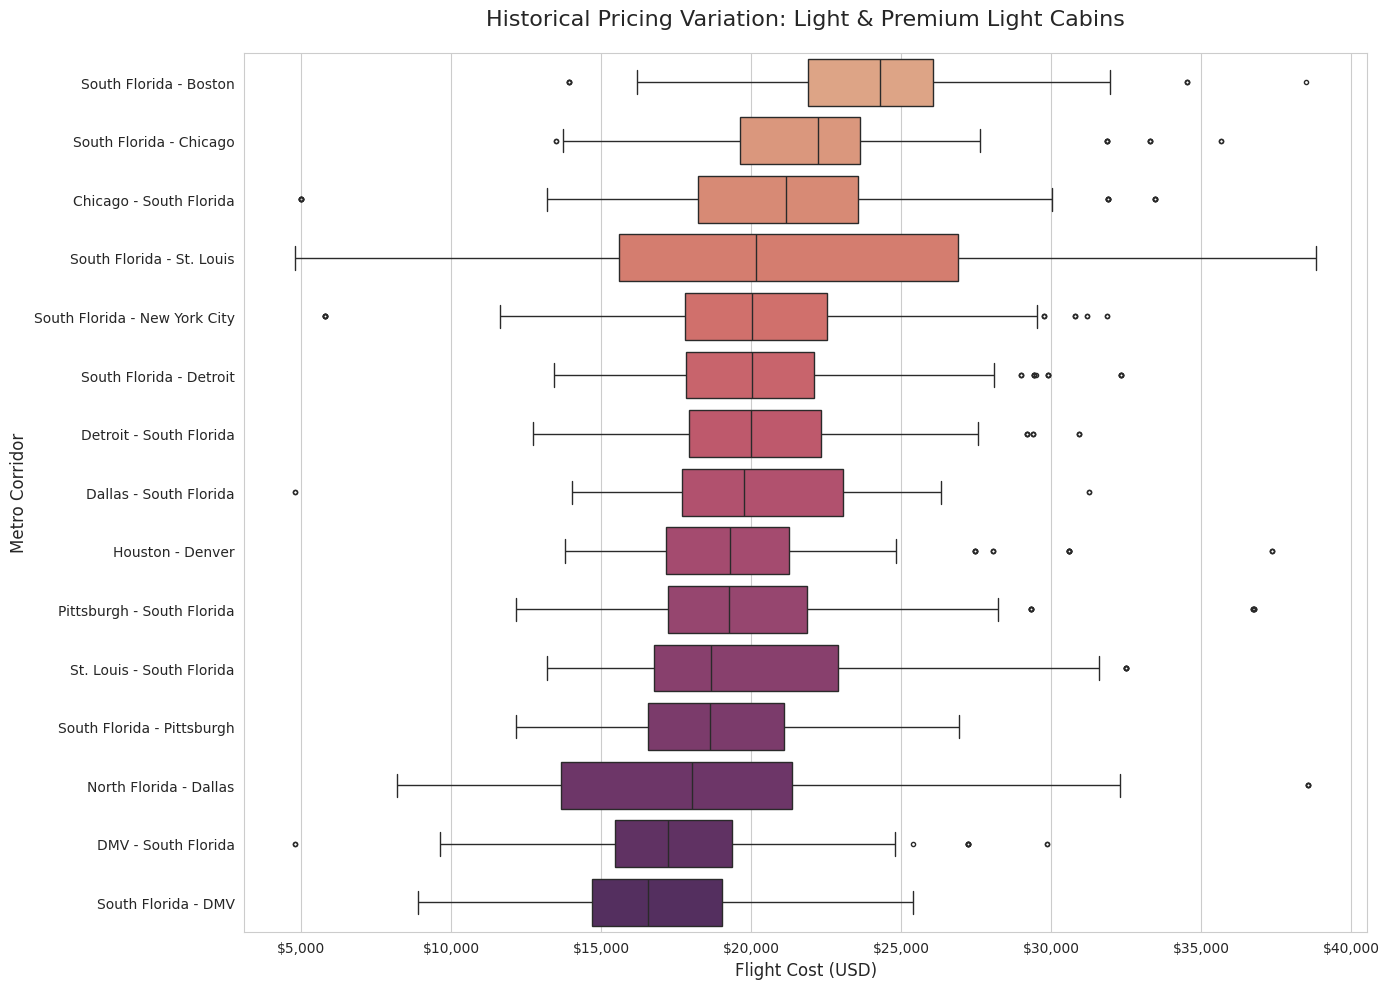

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure the Metro/Corridor logic is applied to the full dataset
icao_to_metro = dict(zip(df_icao['icao'], df_icao['metro']))
df_bookings['from_metro'] = df_bookings['flightoriginAirport'].map(icao_to_metro)
df_bookings['to_metro'] = df_bookings['flightdestinationAirport'].map(icao_to_metro)
df_bookings['corridor'] = df_bookings['from_metro'] + ' - ' + df_bookings['to_metro']

# 2. Apply your requested filters (No date restriction)
target_cabins = ['Light', 'Premium Light']

df_all_time = df_bookings[
    (df_bookings['flightStatus'] == 'Flown') &
    (df_bookings['flightactualAircraftCabinName'].isin(target_cabins)) &
    (df_bookings['flightcost'] > 0)
].copy()

# 3. Your specific unique corridors from the 15-line list
requested_corridors = [
    'DMV - South Florida', 
    'South Florida - DMV',
    'South Florida - Chicago', 
    'Chicago - South Florida',
    'South Florida - New York City',
    'South Florida - Detroit', 
    'Detroit - South Florida',
    'South Florida - Pittsburgh', 
    'St. Louis - South Florida',
    'North Florida - Dallas',
    'Pittsburgh - South Florida',
    'South Florida - St. Louis',
    'Dallas - South Florida',
    'South Florida - Boston',
    'Houston - Denver'
]

# 4. Slice the data
df_plot = df_all_time[df_all_time['corridor'].isin(requested_corridors)].copy()

# 5. Build the "Market Standard" Box Plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# We sort by the median price so the "Premium" routes are at the top
order = df_plot.groupby('corridor')['flightcost'].median().sort_values(ascending=False).index

ax = sns.boxplot(
    data=df_plot, 
    y='corridor', 
    x='flightcost', 
    order=order,
    palette="flare",
    fliersize=3 # Size of the outlier dots
)

# Professional Formatting
plt.title('Historical Pricing Variation: Light & Premium Light Cabins', fontsize=16, pad=20)
plt.xlabel('Flight Cost (USD)', fontsize=12)
plt.ylabel('Metro Corridor', fontsize=12)

# Formatting the X-axis for currency
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${format(int(x), ",")}'))

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_64469/281965973.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


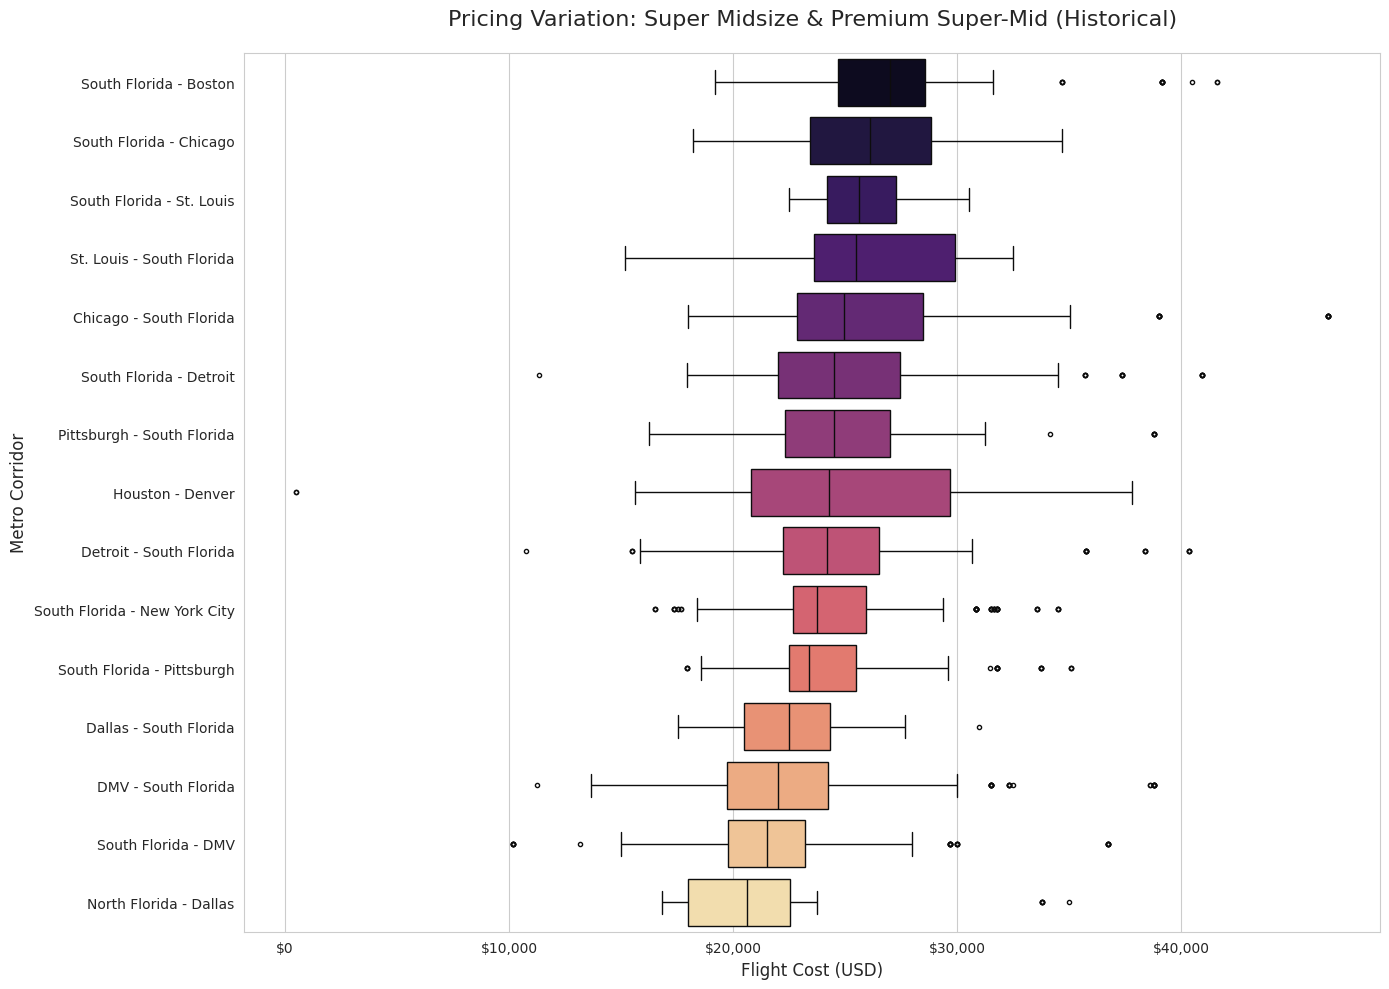

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure Metro/Corridor logic is fresh
icao_to_metro = dict(zip(df_icao['icao'], df_icao['metro']))
df_bookings['from_metro'] = df_bookings['flightoriginAirport'].map(icao_to_metro)
df_bookings['to_metro'] = df_bookings['flightdestinationAirport'].map(icao_to_metro)
df_bookings['corridor'] = df_bookings['from_metro'] + ' - ' + df_bookings['to_metro']

# 2. Apply Filters for Midsize Cabins
mid_cabins = ['Super Midsize', 'Premium Super-Mid']

df_mid_all = df_bookings[
    (df_bookings['flightStatus'] == 'Flown') &
    (df_bookings['flightactualAircraftCabinName'].isin(mid_cabins)) &
    (df_bookings['flightcost'] > 0)
].copy()

# 3. Your target corridors (The 12 unique routes)
target_corridors = [
    'DMV - South Florida', 
    'South Florida - DMV',
    'South Florida - Chicago', 
    'Chicago - South Florida',
    'South Florida - New York City',
    'South Florida - Detroit', 
    'Detroit - South Florida',
    'South Florida - Pittsburgh', 
    'St. Louis - South Florida',
    'North Florida - Dallas',
    'Pittsburgh - South Florida',
    'South Florida - St. Louis',
    'Dallas - South Florida',
    'South Florida - Boston',
    'Houston - Denver'
]

# 4. Isolate the data
df_plot_mid = df_mid_all[df_mid_all['corridor'].isin(target_corridors)].copy()

# 5. Build the Box Plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Sorting by Median to show the pricing hierarchy
order = df_plot_mid.groupby('corridor')['flightcost'].median().sort_values(ascending=False).index

ax = sns.boxplot(
    data=df_plot_mid,
    y='corridor',
    x='flightcost',
    order=order,
    palette="magma", 
    fliersize=3
)

# Professional Formatting
plt.title('Pricing Variation: Super Midsize & Premium Super-Mid (Historical)', fontsize=16, pad=20)
plt.xlabel('Flight Cost (USD)', fontsize=12)
plt.ylabel('Metro Corridor', fontsize=12)

# X-axis as currency
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${format(int(x), ",")}'))

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_64469/4042923278.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_bookings['YearMonth'] = df_bookings['flightET'].dt.to_period('M').astype(str)
/var/tmp/ipykernel_64469/4042923278.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)
/var/tmp/ipykernel_64469/4042923278.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final[df_final['Cabin_Group'] == 'Light Jets'],
/var/tmp/ipykernel_64469/4042923278.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final[df_final['Cabin_

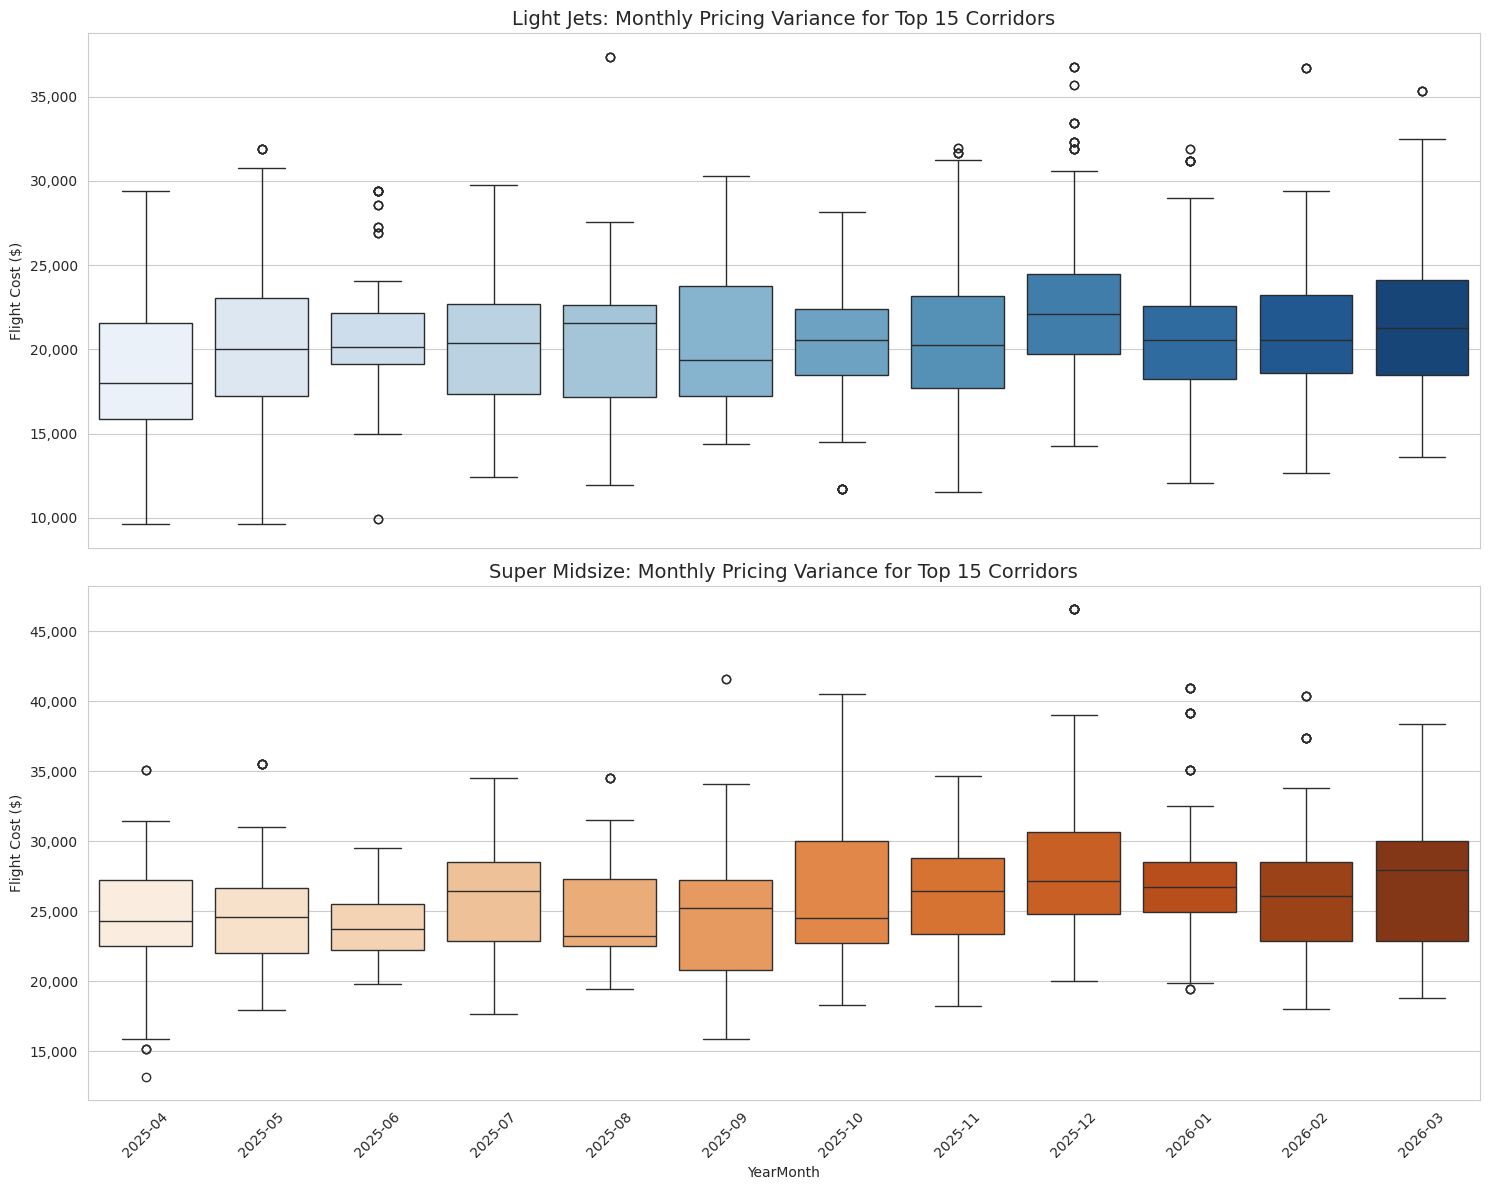

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. COLUMN NAME SAFETY CHECK
time_col = 'flightEstimatedDepartureTime' 

if time_col not in df_bookings.columns:
    print(f"❌ Error: {time_col} not found. Available columns are:")
    print(df_bookings.columns.tolist())
else:
    # 2. PREPARE THE TIME DATA & CORRIDORS
    df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
    df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')
    
    # Mapping metros to create the corridor column
    icao_to_metro = dict(zip(df_icao['icao'], df_icao['metro']))
    df_bookings['from_metro'] = df_bookings['flightoriginAirport'].map(icao_to_metro)
    df_bookings['to_metro'] = df_bookings['flightdestinationAirport'].map(icao_to_metro)
    df_bookings['corridor'] = df_bookings['from_metro'] + ' - ' + df_bookings['to_metro']

    # Time labels
    df_bookings['YearMonth'] = df_bookings['flightET'].dt.to_period('M').astype(str)
    df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)

    # 3. DEFINE FILTERS
    light_group = ['Light', 'Premium Light']
    mid_group = ['Super Midsize', 'Premium Super-Mid']
    target_quarters = ['2025Q2', '2025Q3', '2025Q4', '2026Q1']
    
    target_corridors = [
    'DMV - South Florida', 
    'South Florida - DMV',
    'South Florida - Chicago', 
    'Chicago - South Florida',
    'South Florida - New York City',
    'South Florida - Detroit', 
    'Detroit - South Florida',
    'South Florida - Pittsburgh', 
    'St. Louis - South Florida',
    'North Florida - Dallas',
    'Pittsburgh - South Florida',
    'South Florida - St. Louis',
    'Dallas - South Florida',
    'South Florida - Boston',
    'Houston - Denver'
]
    # 4. APPLY MASTER FILTER (Time + Status + Cost + SPECIFIC CORRIDORS)
    df_time_analysis = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') &
        (df_bookings['flightcost'] > 0) &
        (df_bookings['Quarter'].isin(target_quarters)) &
        (df_bookings['corridor'].isin(target_corridors)) # <-- CORRIDOR FILTER ADDED HERE
    ].copy()

    # Tag Cabin Groups
    df_time_analysis['Cabin_Group'] = 'Other'
    df_time_analysis.loc[df_time_analysis['flightactualAircraftCabinName'].isin(light_group), 'Cabin_Group'] = 'Light Jets'
    df_time_analysis.loc[df_time_analysis['flightactualAircraftCabinName'].isin(mid_group), 'Cabin_Group'] = 'Super Midsize'

    df_final = df_time_analysis[df_time_analysis['Cabin_Group'] != 'Other'].sort_values('flightET')

    # 5. GENERATE THE SUBPLOTS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
    sns.set_style("whitegrid")

    # Plot 1: Light Jets
    sns.boxplot(data=df_final[df_final['Cabin_Group'] == 'Light Jets'], 
                x='YearMonth', y='flightcost', ax=ax1, palette="Blues")
    ax1.set_title(f'Light Jets: Monthly Pricing Variance for Top 15 Corridors', fontsize=14)
    ax1.set_ylabel('Flight Cost ($)')

    # Plot 2: Super Midsize
    sns.boxplot(data=df_final[df_final['Cabin_Group'] == 'Super Midsize'], 
                x='YearMonth', y='flightcost', ax=ax2, palette="Oranges")
    ax2.set_title(f'Super Midsize: Monthly Pricing Variance for Top 15 Corridors', fontsize=14)
    ax2.set_ylabel('Flight Cost ($)')

    plt.xticks(rotation=45)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.tight_layout()
    plt.show()

/var/tmp/ipykernel_64469/731501073.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_density, x='Price_Bucket', y='Total_Revenue', ax=ax1, palette="viridis", alpha=0.7)


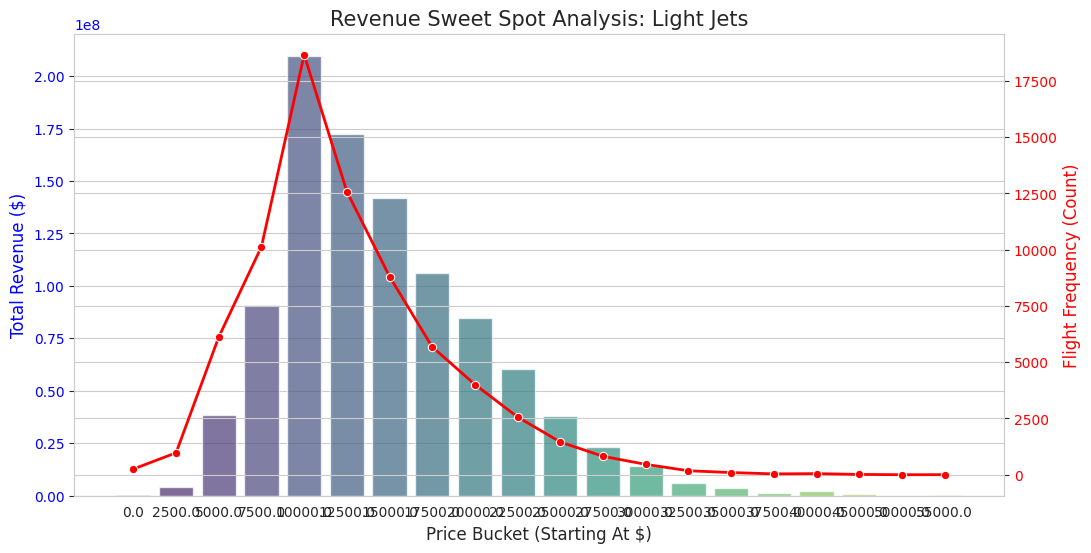


--- Day of Week Profile: Light Jets ---
              Avg_Price  Total_Revenue  Count
DayOfWeek                                    
Monday     13814.154463   1.373403e+08   9942
Tuesday    13708.201585   1.191791e+08   8694
Wednesday  13684.748729   1.238607e+08   9051
Thursday   13604.422699   1.410234e+08  10366
Friday     13504.110130   1.547976e+08  11463
Saturday   14057.119399   1.438465e+08  10233
Sunday     13671.911103   1.797036e+08  13144


/var/tmp/ipykernel_64469/731501073.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_density, x='Price_Bucket', y='Total_Revenue', ax=ax1, palette="viridis", alpha=0.7)


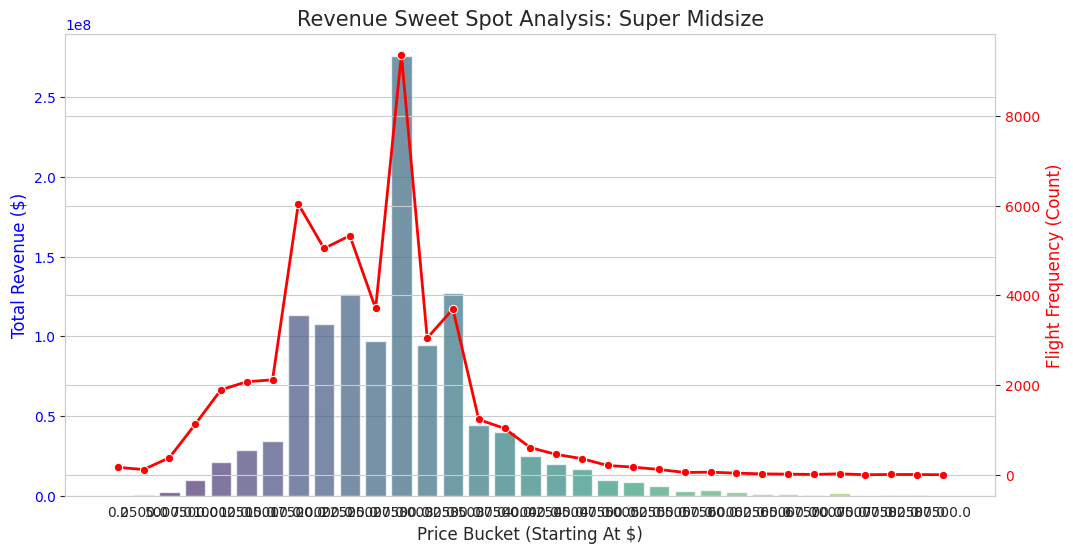


--- Day of Week Profile: Super Midsize ---
              Avg_Price  Total_Revenue  Count
DayOfWeek                                    
Monday     25350.509301   1.756030e+08   6927
Tuesday    24607.980678   1.437598e+08   5842
Wednesday  24359.971705   1.514703e+08   6218
Thursday   25103.042511   1.755456e+08   6993
Friday     25152.123621   1.920868e+08   7637
Saturday   26033.577627   1.751799e+08   6729
Sunday     25838.867950   2.104576e+08   8145


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Time Data
time_col = 'flightEstimatedDepartureTime'
df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')
df_bookings['DayOfWeek'] = df_bookings['flightET'].dt.day_name()
df_bookings['Month'] = df_bookings['flightET'].dt.month_name()

# 2. Function to Calculate Revenue Density
def analyze_revenue_sweet_spot(cabin_list, cabin_label):
    df = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') & 
        (df_bookings['flightactualAircraftCabinName'].isin(cabin_list)) &
        (df_bookings['flightcost'] > 0)
    ].copy()
    
    # Create Price Buckets (e.g., every $2,500)
    bin_size = 2500
    df['Price_Bucket'] = (df['flightcost'] // bin_size) * bin_size
    
    # Aggregate Revenue and Frequency
    revenue_density = df.groupby('Price_Bucket').agg(
        Total_Revenue=('flightcost', 'sum'),
        Flight_Count=('flightcost', 'count')
    ).reset_index()
    
    # 3. Visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=revenue_density, x='Price_Bucket', y='Total_Revenue', ax=ax1, palette="viridis", alpha=0.7)
    ax1.set_ylabel('Total Revenue ($)', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    
    ax2 = ax1.twinx()
    sns.lineplot(data=revenue_density, x=range(len(revenue_density)), y='Flight_Count', ax=ax2, color='r', marker='o', linewidth=2)
    ax2.set_ylabel('Flight Frequency (Count)', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')
    
    plt.title(f'Revenue Sweet Spot Analysis: {cabin_label}', fontsize=15)
    ax1.set_xlabel('Price Bucket (Starting At $)', fontsize=12)
    plt.show()

    # 4. Day of Week Elasticity Table
    dow_stats = df.groupby('DayOfWeek').agg(
        Avg_Price=('flightcost', 'mean'),
        Total_Revenue=('flightcost', 'sum'),
        Count=('flightcost', 'count')
    ).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
    
    print(f"\n--- Day of Week Profile: {cabin_label} ---")
    print(dow_stats)

# Run Analysis
analyze_revenue_sweet_spot(['Light', 'Premium Light'], 'Light Jets')
analyze_revenue_sweet_spot(['Super Midsize', 'Premium Super-Mid'], 'Super Midsize')

/var/tmp/ipykernel_64469/516070989.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_data.index, y=dow_data['Avg_Price'], ax=ax1, palette="Blues_d", alpha=0.7)
/var/tmp/ipykernel_64469/516070989.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_data.index, y=month_data['Avg_Price'], ax=ax2, palette="Greens_d", alpha=0.7)


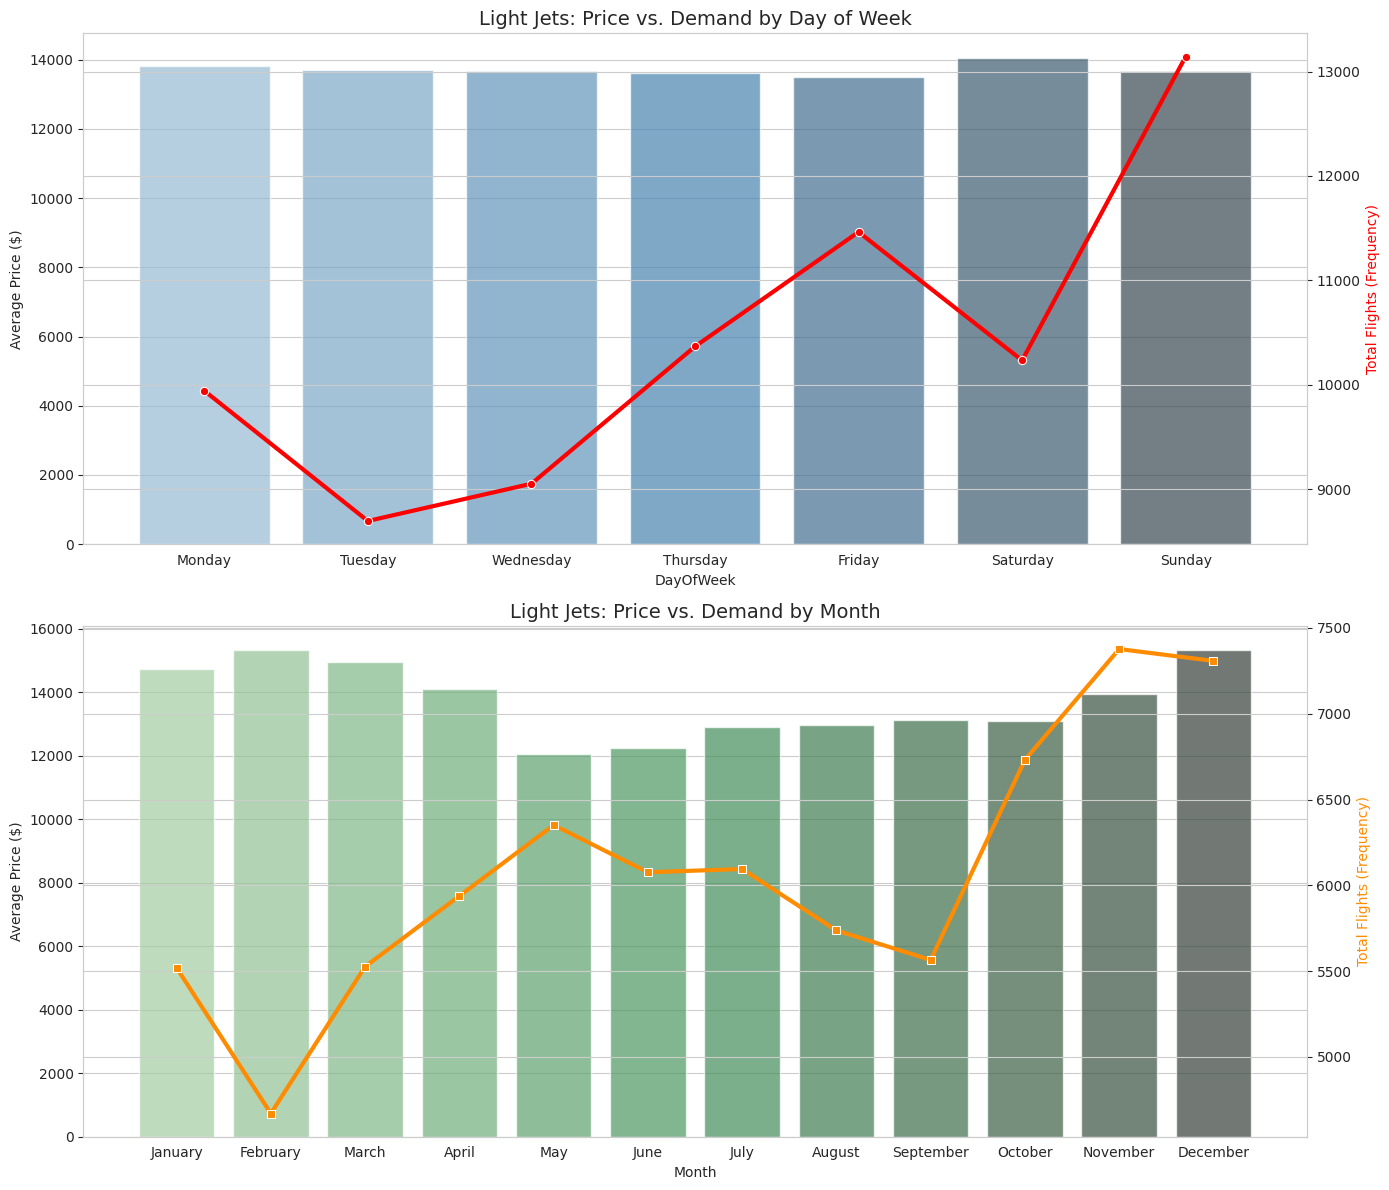


--- Light Jets Tactical Table ---
           count          mean     median
DayOfWeek                                
Monday      9942  13814.154463  12852.000
Tuesday     8694  13708.201585  12452.550
Wednesday   9051  13684.748729  12486.500
Thursday   10366  13604.422699  12485.225
Friday     11463  13504.110130  12411.000
Saturday   10233  14057.119399  12911.500
Sunday     13144  13671.911103  12571.500


/var/tmp/ipykernel_64469/516070989.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_data.index, y=dow_data['Avg_Price'], ax=ax1, palette="Blues_d", alpha=0.7)
/var/tmp/ipykernel_64469/516070989.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_data.index, y=month_data['Avg_Price'], ax=ax2, palette="Greens_d", alpha=0.7)


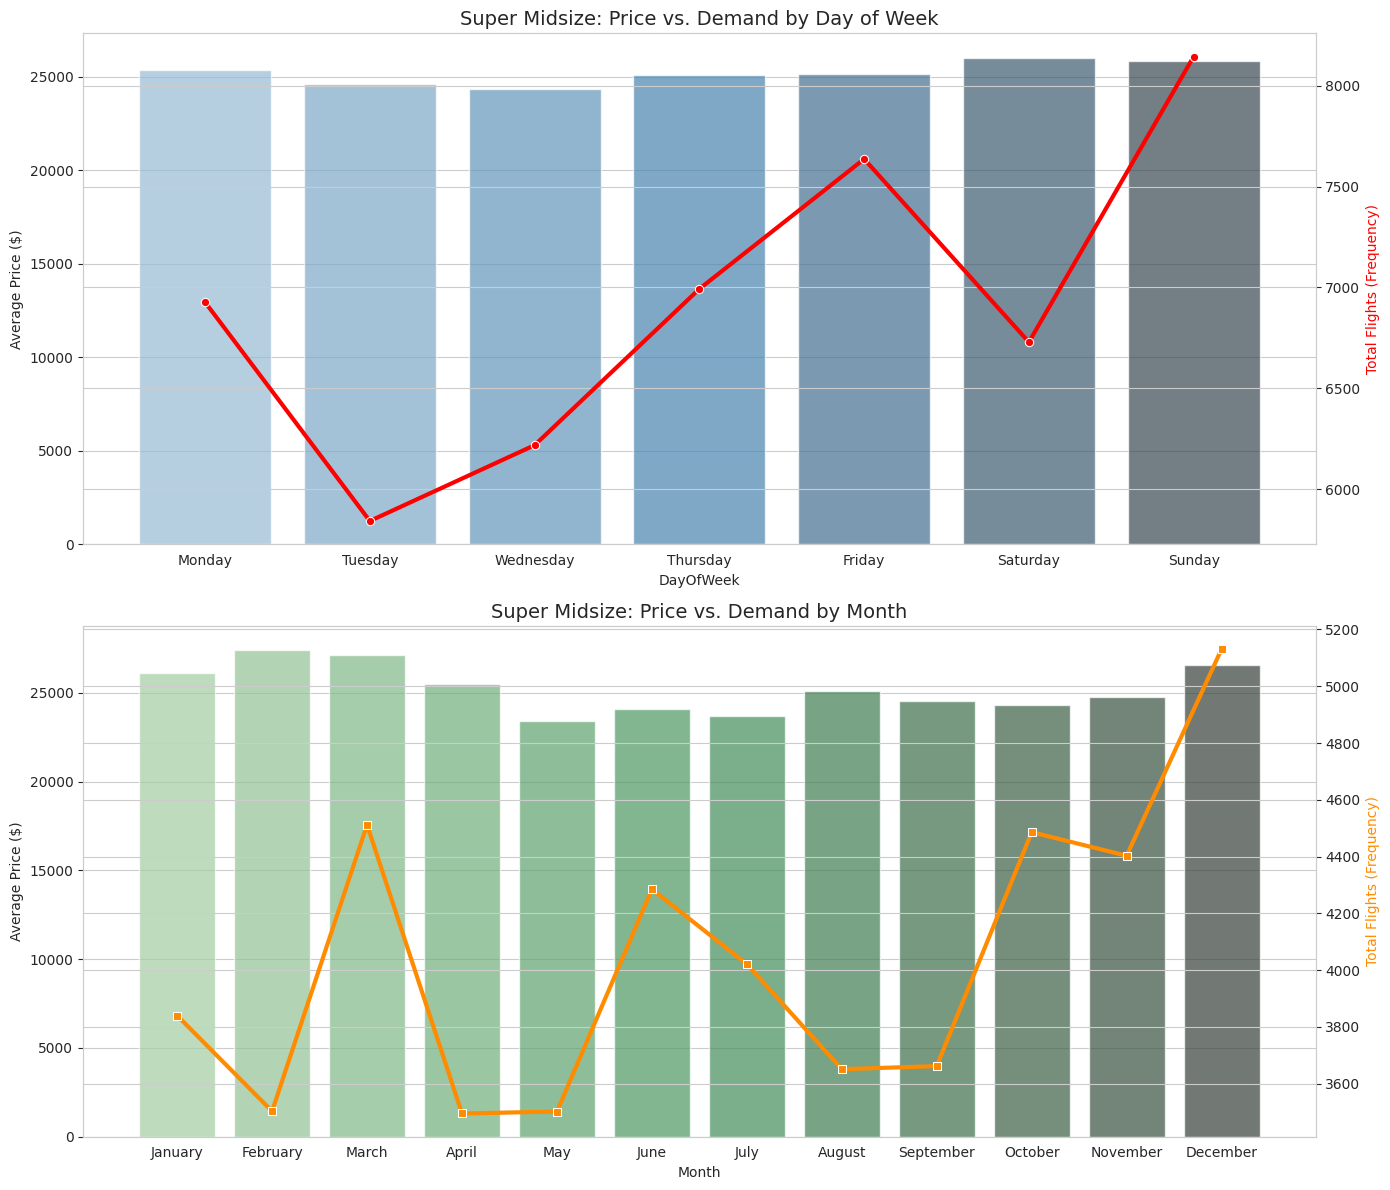


--- Super Midsize Tactical Table ---
           count          mean     median
DayOfWeek                                
Monday      6927  25350.509301  25636.500
Tuesday     5842  24607.980678  24396.075
Wednesday   6218  24359.971705  24167.000
Thursday    6993  25103.042511  25063.000
Friday      7637  25152.123621  24286.500
Saturday    6729  26033.577627  26163.000
Sunday      8145  25838.867950  25368.760


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP TIME DATA (Eastern Time)
time_col = 'flightEstimatedDepartureTime'
df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')

# Extracting categorical time dimensions
df_bookings['DayOfWeek'] = df_bookings['flightET'].dt.day_name()
df_bookings['Month'] = df_bookings['flightET'].dt.month_name()

# Sort order for cleaner graphs
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 2. DEFINE GROUPS
light_group = ['Light', 'Premium Light']
mid_group = ['Super Midsize', 'Premium Super-Mid']

def run_comprehensive_demand_analysis(cabin_list, label):
    # Filter for Flown data
    df = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') &
        (df_bookings['flightactualAircraftCabinName'].isin(cabin_list)) &
        (df_bookings['flightcost'] > 0)
    ].copy()

    # Create two subplots: One for Day of Week, One for Month
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # --- PLOT A: DAY OF WEEK DEMAND ---
    dow_data = df.groupby('DayOfWeek').agg(
        Avg_Price=('flightcost', 'mean'),
        Frequency=('flightcost', 'count')
    ).reindex(dow_order)

    sns.barplot(x=dow_data.index, y=dow_data['Avg_Price'], ax=ax1, palette="Blues_d", alpha=0.7)
    ax1_twin = ax1.twinx()
    sns.lineplot(x=dow_data.index, y=dow_data['Frequency'], ax=ax1_twin, color='red', marker='o', linewidth=3)
    
    ax1.set_title(f'{label}: Price vs. Demand by Day of Week', fontsize=14)
    ax1.set_ylabel('Average Price ($)')
    ax1_twin.set_ylabel('Total Flights (Frequency)', color='red')

    # --- PLOT B: MONTHLY SEASONALITY ---
    month_data = df.groupby('Month').agg(
        Avg_Price=('flightcost', 'mean'),
        Frequency=('flightcost', 'count')
    ).reindex(month_order).dropna()

    sns.barplot(x=month_data.index, y=month_data['Avg_Price'], ax=ax2, palette="Greens_d", alpha=0.7)
    ax2_twin = ax2.twinx()
    sns.lineplot(x=month_data.index, y=month_data['Frequency'], ax=ax2_twin, color='darkorange', marker='s', linewidth=3)
    
    ax2.set_title(f'{label}: Price vs. Demand by Month', fontsize=14)
    ax2.set_ylabel('Average Price ($)')
    ax2_twin.set_ylabel('Total Flights (Frequency)', color='darkorange')

    plt.tight_layout()
    plt.show()

    # 3. OUTPUT ELASTICITY INSIGHT TABLE
    print(f"\n--- {label} Tactical Table ---")
    summary = df.groupby('DayOfWeek')['flightcost'].agg(['count', 'mean', 'median']).reindex(dow_order)
    print(summary)

# EXECUTE
run_comprehensive_demand_analysis(light_group, "Light Jets")
run_comprehensive_demand_analysis(mid_group, "Super Midsize")

/var/tmp/ipykernel_64469/2749127544.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)


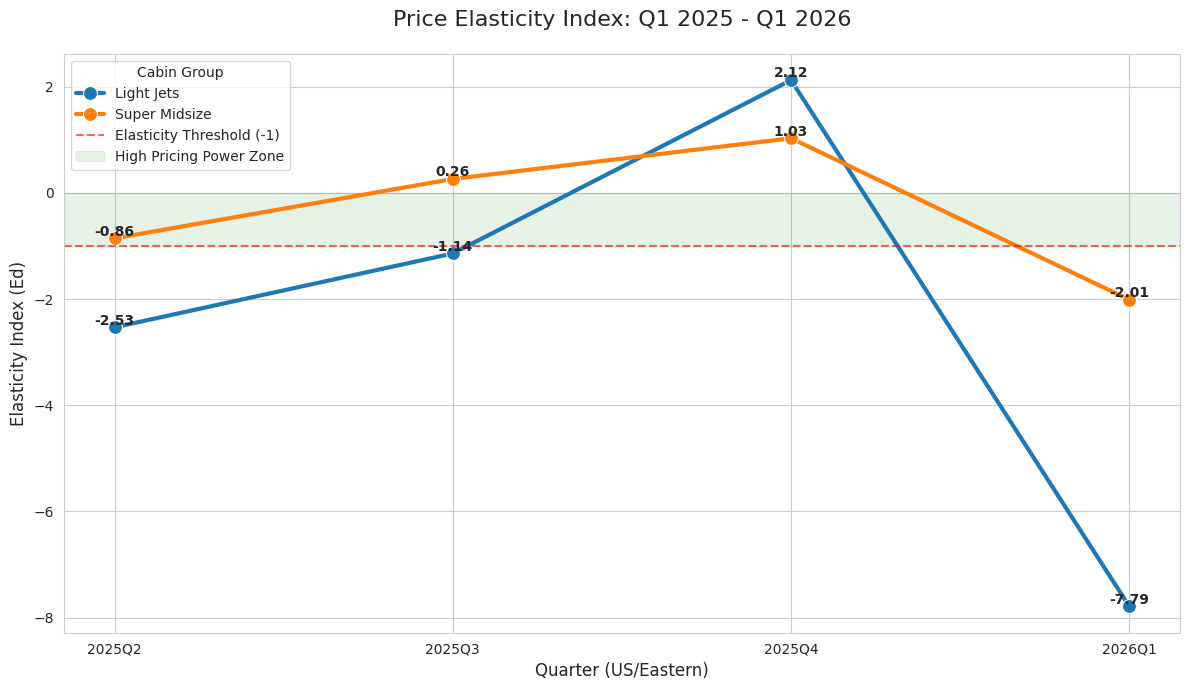


--- Final Elasticity Dataset for Nexara ---


,Quarter,Quantity,Avg_Price,Q_mid,P_mid,Pct_Change_Q,Pct_Change_P,Elasticity_Index,Cabin_Type
1,2025Q2,8859,13428.827789,8323.0,13779.122770,0.128800,-0.050844,-2.533218,Light Jets
2,2025Q3,8605,13775.284982,8732.0,13602.056385,-0.029088,0.025471,-1.142023,Light Jets
3,2025Q4,10682,15248.202590,9643.5,14511.743786,0.215378,0.101498,2.121988,Light Jets
4,2026Q1,7928,15838.948942,9305.0,15543.575766,-0.295970,0.038006,-7.787489,Light Jets
6,2025Q2,6126,24389.041361,6049.0,24756.521645,0.025459,-0.029688,-0.857556,Super Midsize
7,2025Q3,6147,24711.995154,6136.5,24550.518258,0.003422,0.013155,0.260147,Super Midsize
8,2025Q4,6701,26876.838999,6424.0,25794.417076,0.086239,0.083927,1.027551,Super Midsize
9,2026Q1,5883,28670.974382,6292.0,27773.906690,-0.130006,0.064598,-2.012548,Super Midsize


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TIME PREP (Fixed UserWarning by converting to string immediately)
time_col = 'flightEstimatedDepartureTime'
df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')
# Convert to string right away to avoid PeriodArray timezone issues
df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)

# Define requested timeframe
target_quarters = ['2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']

# 2. DEFINE CABIN GROUPS
groups = {
    'Light Jets': ['Light', 'Premium Light'],
    'Super Midsize': ['Super Midsize', 'Premium Super-Mid']
}

def calculate_quarterly_ped(cabin_list, label):
    df = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') &
        (df_bookings['flightactualAircraftCabinName'].isin(cabin_list)) &
        (df_bookings['flightcost'] > 0) &
        (df_bookings['Quarter'].isin(target_quarters))
    ].copy()
    
    # Aggregate
    stats = df.groupby('Quarter').agg(
        Quantity=('flightcost', 'count'),
        Avg_Price=('flightcost', 'mean')
    ).reindex(target_quarters).reset_index()
    
    # Midpoint Calculation
    stats['Q_mid'] = (stats['Quantity'] + stats['Quantity'].shift(1)) / 2
    stats['P_mid'] = (stats['Avg_Price'] + stats['Avg_Price'].shift(1)) / 2
    stats['Pct_Change_Q'] = (stats['Quantity'] - stats['Quantity'].shift(1)) / stats['Q_mid']
    stats['Pct_Change_P'] = (stats['Avg_Price'] - stats['Avg_Price'].shift(1)) / stats['P_mid']
    
    stats['Elasticity_Index'] = stats['Pct_Change_Q'] / stats['Pct_Change_P']
    stats['Cabin_Type'] = label
    return stats

# 3. COMPUTE & FIX INDEX (This prevents the ValueError)
light_ped = calculate_quarterly_ped(groups['Light Jets'], 'Light Jets')
mid_ped = calculate_quarterly_ped(groups['Super Midsize'], 'Super Midsize')

# reset_index(drop=True) ensures the index is unique (0, 1, 2, 3...)
combined_ped = pd.concat([light_ped, mid_ped]).reset_index(drop=True)

# 4. GRAPHICAL REPRESENTATION
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# We use the clean combined_ped here
ax = sns.lineplot(data=combined_ped, x='Quarter', y='Elasticity_Index', 
                  hue='Cabin_Type', marker='o', linewidth=3, markersize=10)

# Reference Lines
plt.axhline(-1, color='red', linestyle='--', alpha=0.6, label='Elasticity Threshold (-1)')
plt.axhspan(-1, 0, color='green', alpha=0.1, label='High Pricing Power Zone')

plt.title('Price Elasticity Index: Q1 2025 - Q1 2026', fontsize=16, pad=20)
plt.ylabel('Elasticity Index (Ed)', fontsize=12)
plt.xlabel('Quarter (US/Eastern)', fontsize=12)
plt.legend(title='Cabin Group', loc='upper left')

# Smart Annotations (only if not NaN)
for i in range(len(combined_ped)):
    val = combined_ped.iloc[i]['Elasticity_Index']
    if not np.isnan(val):
        plt.text(combined_ped.iloc[i]['Quarter'], val + 0.05, f"{val:.2f}", 
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. FINAL TABLE FOR MANAGER
print("\n--- Final Elasticity Dataset for Nexara ---")
display(combined_ped.dropna(subset=['Elasticity_Index']))

--- ANALYZING LIGHT JETS ---


/var/tmp/ipykernel_64469/4146991646.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)


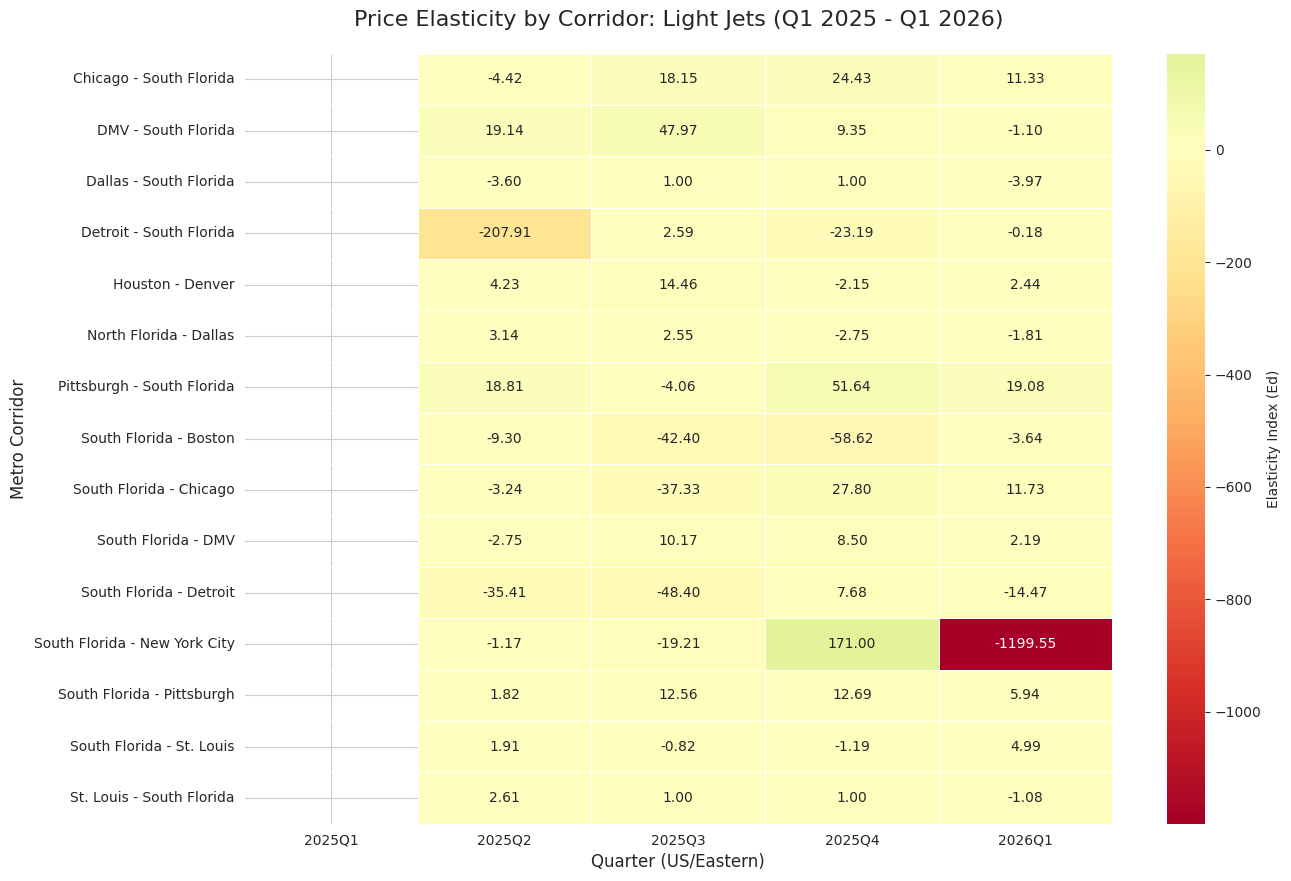


--- ANALYZING SUPER MIDSIZE ---


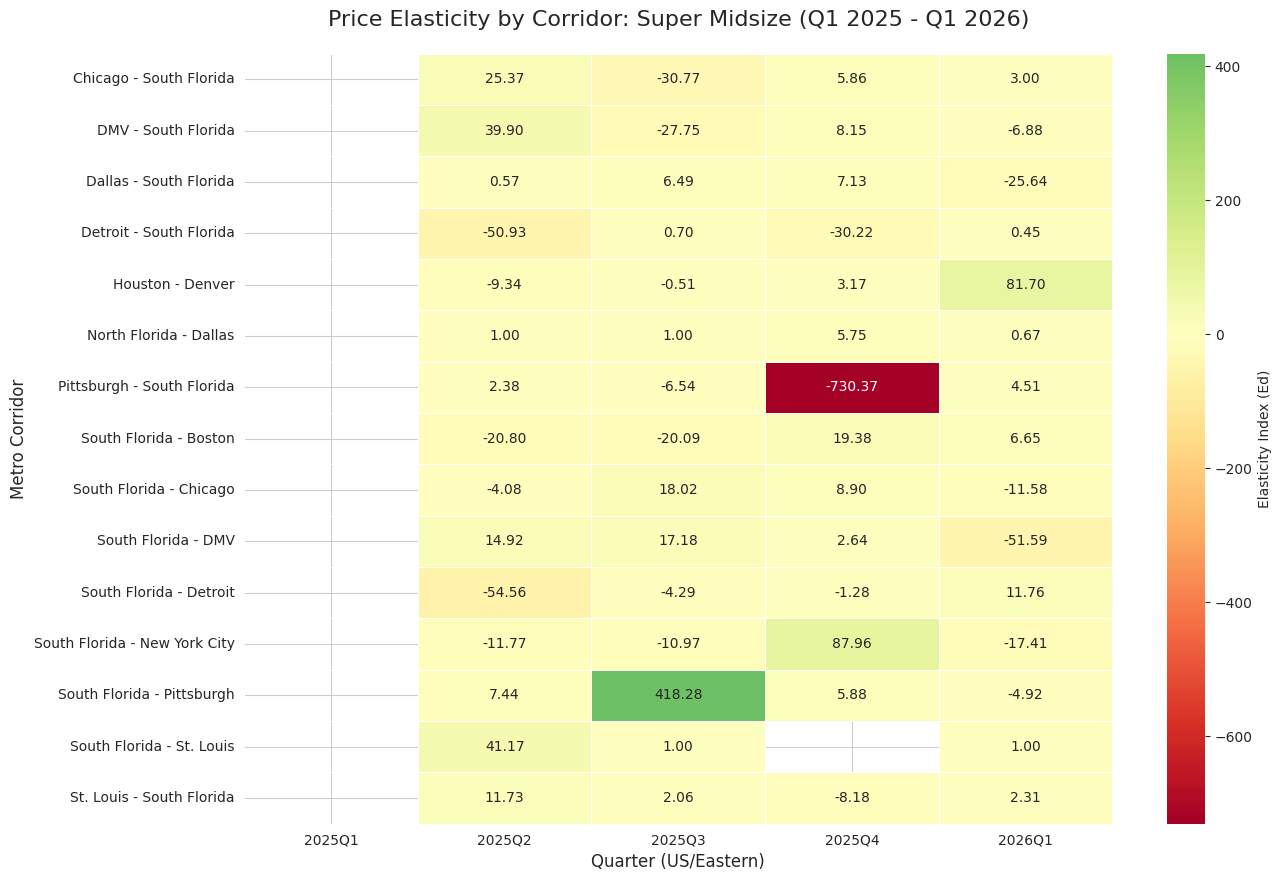

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DATA PREP & CORRIDOR DEFINITION
target_corridors = [
    'DMV - South Florida', 'South Florida - DMV', 'South Florida - Chicago', 
    'Chicago - South Florida', 'South Florida - New York City', 'South Florida - Detroit', 
    'Detroit - South Florida', 'South Florida - Pittsburgh', 'St. Louis - South Florida', 
    'North Florida - Dallas', 'Pittsburgh - South Florida', 'South Florida - St. Louis', 
    'Dallas - South Florida', 'South Florida - Boston', 'Houston - Denver'
]

# Ensure Eastern Time and Quarter strings
time_col = 'flightEstimatedDepartureTime'
df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')
df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)

# Filter for relevant timeframe
target_quarters = ['2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']

# 2. CORE ANALYTICS FUNCTION
def run_corridor_ped_analysis(cabin_list, cabin_label):
    # Filter by Status, Cabin, and Corridor
    df = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') &
        (df_bookings['flightactualAircraftCabinName'].isin(cabin_list)) &
        (df_bookings['flightcost'] > 0) &
        (df_bookings['corridor'].isin(target_corridors)) &
        (df_bookings['Quarter'].isin(target_quarters))
    ].copy()

    # Aggregate Quantity and Avg Price
    stats = df.groupby(['corridor', 'Quarter']).agg(
        Quantity=('flightcost', 'count'),
        Avg_Price=('flightcost', 'mean')
    ).reset_index()

    # Ensure all quarters are present for each corridor for consistent shift() math
    all_combinations = pd.MultiIndex.from_product(
        [target_corridors, target_quarters], names=['corridor', 'Quarter']
    ).to_frame(index=False)
    
    stats = pd.merge(all_combinations, stats, on=['corridor', 'Quarter'], how='left').fillna(0)
    stats = stats.sort_values(['corridor', 'Quarter'])

    # Midpoint/Arc Elasticity Logic per Corridor
    # Using groupby('corridor') ensures we don't compare the end of one route to the start of another
    g = stats.groupby('corridor')
    
    stats['Q_mid'] = g['Quantity'].transform(lambda x: (x + x.shift(1)) / 2)
    stats['P_mid'] = g['Avg_Price'].transform(lambda x: (x + x.shift(1)) / 2)
    
    stats['Pct_Change_Q'] = (stats['Quantity'] - g['Quantity'].shift(1)) / stats['Q_mid']
    stats['Pct_Change_P'] = (stats['Avg_Price'] - g['Avg_Price'].shift(1)) / stats['P_mid']
    
    # Calculate Index and handle potential divide-by-zero or NaN
    stats['Elasticity'] = stats['Pct_Change_Q'] / stats['Pct_Change_P']
    stats.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 3. HEATMAP VISUALIZATION
    pivot_table = stats.pivot(index='corridor', columns='Quarter', values='Elasticity')
    
    plt.figure(figsize=(14, 10))
    # Red-Yellow-Green map: Green = Inelastic (Power), Red = Elastic (Sensitive)
    # We center at -1.0 because that is the 'Unit Elastic' tipping point
    sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=-1, fmt=".2f",
                linewidths=.5, cbar_kws={'label': 'Elasticity Index (Ed)'})
    
    plt.title(f'Price Elasticity by Corridor: {cabin_label} (Q1 2025 - Q1 2026)', fontsize=16, pad=20)
    plt.ylabel('Metro Corridor', fontsize=12)
    plt.xlabel('Quarter (US/Eastern)', fontsize=12)
    plt.show()
    
    return stats[['corridor', 'Quarter', 'Avg_Price', 'Quantity', 'Elasticity']].dropna()

# 4. RUN BOTH CATEGORIES
print("--- ANALYZING LIGHT JETS ---")
light_results = run_corridor_ped_analysis(['Light', 'Premium Light'], 'Light Jets')

print("\n--- ANALYZING SUPER MIDSIZE ---")
mid_results = run_corridor_ped_analysis(['Super Midsize', 'Premium Super-Mid'], 'Super Midsize')

/var/tmp/ipykernel_64469/1649757261.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)



==================== LIGHT JETS ANALYSIS ====================


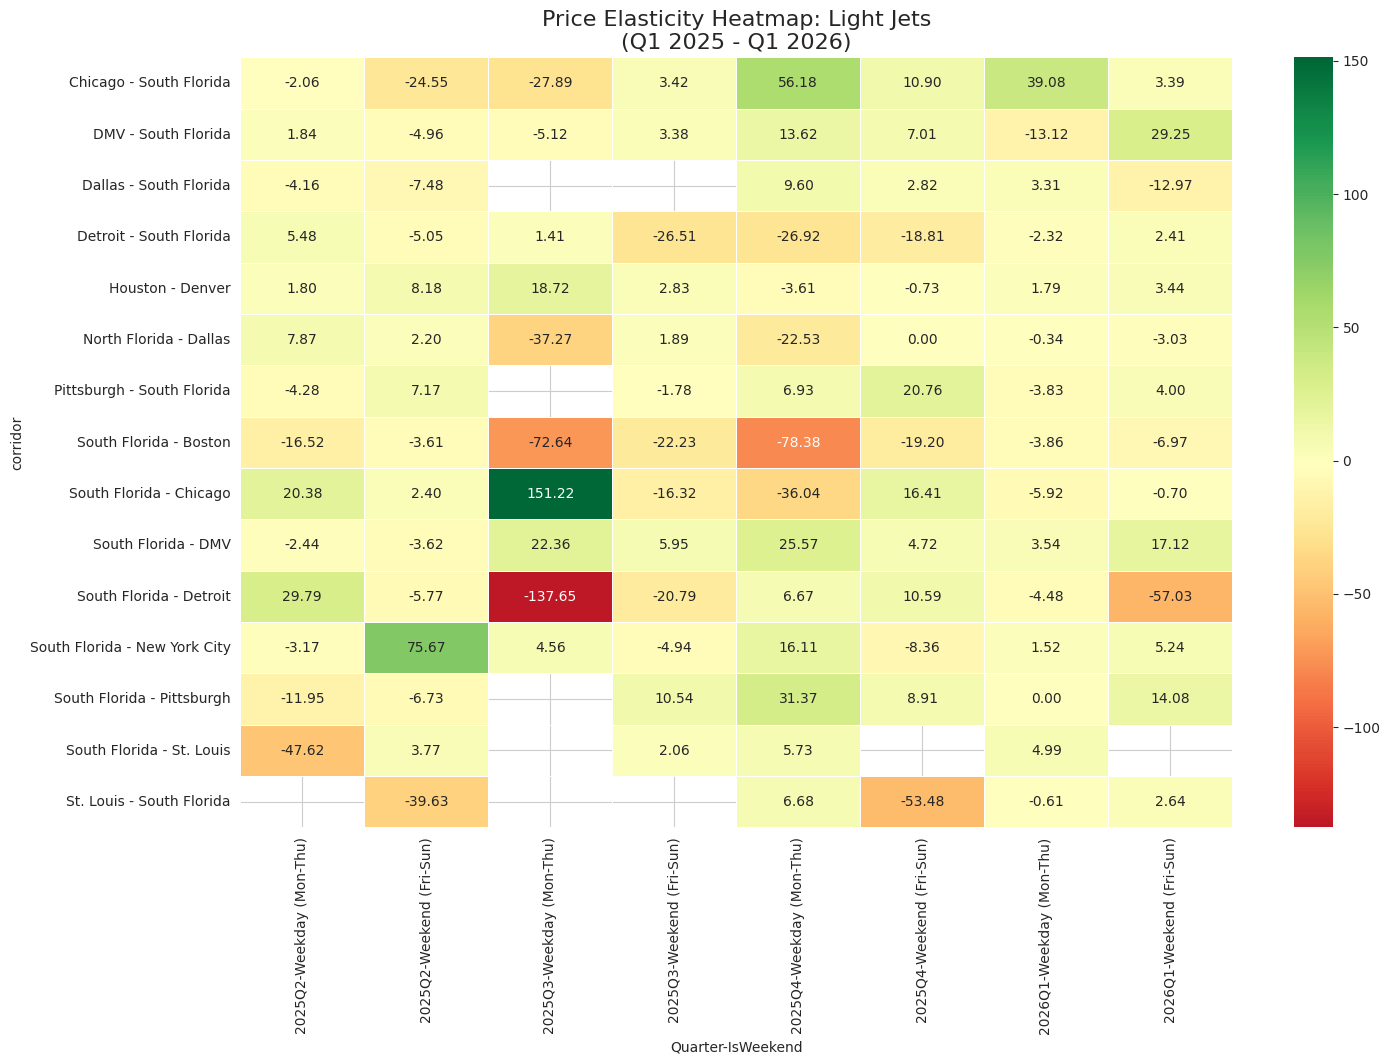


Recent Pricing Sensitivity (Q1 2026):


,corridor,IsWeekend,Avg_Price,Quantity,Elasticity_Index
106,South Florida - Detroit,Weekend (Fri-Sun),23187.088261,69,-57.028960
18,DMV - South Florida,Weekday (Mon-Thu),18664.792923,65,-13.115389
27,Dallas - South Florida,Weekend (Fri-Sun),22555.627273,22,-12.965890
76,South Florida - Boston,Weekend (Fri-Sun),24909.211481,27,-6.968182
85,South Florida - Chicago,Weekday (Mon-Thu),22483.706154,26,-5.918856
105,South Florida - Detroit,Weekday (Mon-Thu),20346.650000,56,-4.484260
75,South Florida - Boston,Weekday (Mon-Thu),28809.457692,13,-3.860349
65,Pittsburgh - South Florida,Weekday (Mon-Thu),24023.362400,25,-3.829004
57,North Florida - Dallas,Weekend (Fri-Sun),27791.330000,2,-3.032010
36,Detroit - South Florida,Weekday (Mon-Thu),20587.663448,87,-2.322409



==================== SUPER MIDSIZE ANALYSIS ====================


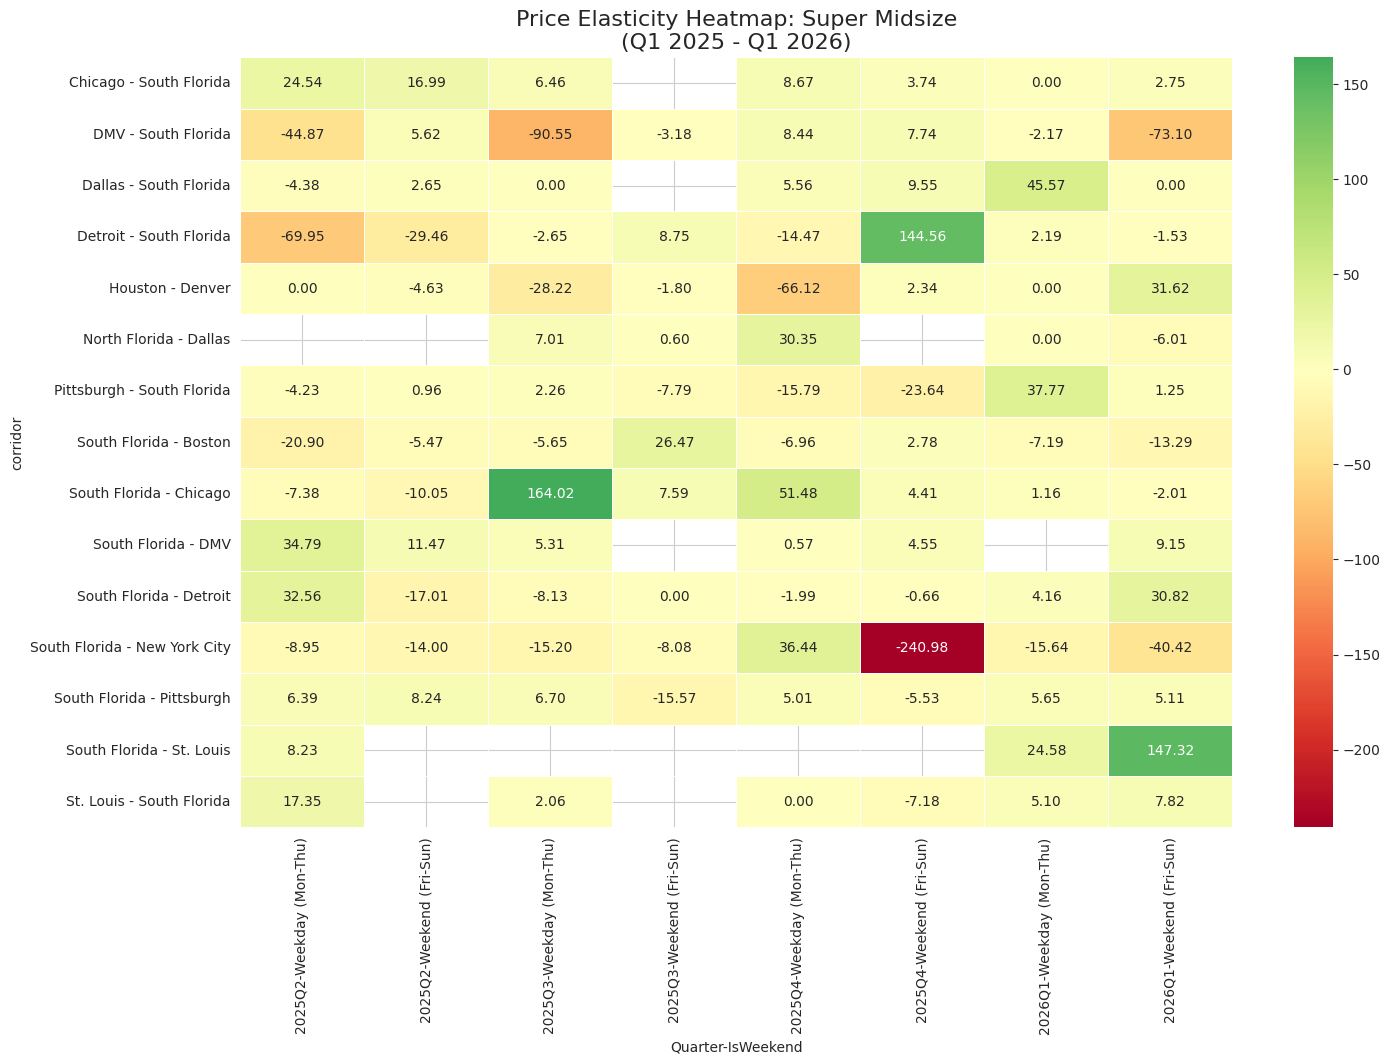


Recent Pricing Sensitivity (Q1 2026):


,corridor,IsWeekend,Avg_Price,Quantity,Elasticity_Index
18,DMV - South Florida,Weekend (Fri-Sun),26045.716552,29,-73.100838
112,South Florida - New York City,Weekend (Fri-Sun),26482.217083,48,-40.421044
111,South Florida - New York City,Weekday (Mon-Thu),24409.459551,89,-15.639719
74,South Florida - Boston,Weekend (Fri-Sun),29459.660889,45,-13.290073
73,South Florida - Boston,Weekday (Mon-Thu),29334.612500,24,-7.192986
54,North Florida - Dallas,Weekend (Fri-Sun),27513.595000,2,-6.014315
17,DMV - South Florida,Weekday (Mon-Thu),28529.015000,16,-2.172219
84,South Florida - Chicago,Weekend (Fri-Sun),25894.507037,27,-2.011903
37,Detroit - South Florida,Weekend (Fri-Sun),29628.702333,30,-1.529038
53,North Florida - Dallas,Weekday (Mon-Thu),32118.100000,6,0.000000


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. SETUP & CONFIGURATION
target_corridors = [
    'DMV - South Florida', 'South Florida - DMV', 'South Florida - Chicago', 
    'Chicago - South Florida', 'South Florida - New York City', 'South Florida - Detroit', 
    'Detroit - South Florida', 'South Florida - Pittsburgh', 'St. Louis - South Florida', 
    'North Florida - Dallas', 'Pittsburgh - South Florida', 'South Florida - St. Louis', 
    'Dallas - South Florida', 'South Florida - Boston', 'Houston - Denver'
]

cabin_groups = {
    'Light Jets': ['Light', 'Premium Light'],
    'Super Midsize': ['Super Midsize', 'Premium Super-Mid']
}

# 2. TIME NORMALIZATION (Eastern Time)
time_col = 'flightEstimatedDepartureTime'
df_bookings[time_col] = pd.to_datetime(df_bookings[time_col], utc=True)
df_bookings['flightET'] = df_bookings[time_col].dt.tz_convert('US/Eastern')
df_bookings['Quarter'] = df_bookings['flightET'].dt.to_period('Q').astype(str)
df_bookings['DayOfWeek'] = df_bookings['flightET'].dt.dayofweek # Mon=0, Sun=6
df_bookings['IsWeekend'] = df_bookings['DayOfWeek'].apply(lambda x: 'Weekend (Fri-Sun)' if x >= 4 else 'Weekday (Mon-Thu)')

target_quarters = ['2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']

# 3. ANALYSIS FUNCTION
def calculate_segmented_elasticity(cabin_list, label):
    # Filter Data
    df = df_bookings[
        (df_bookings['flightStatus'] == 'Flown') &
        (df_bookings['flightactualAircraftCabinName'].isin(cabin_list)) &
        (df_bookings['flightcost'] > 0) &
        (df_bookings['corridor'].isin(target_corridors)) &
        (df_bookings['Quarter'].isin(target_quarters))
    ].copy()

    # Aggregate by Corridor, Quarter, and Weekend Split
    stats = df.groupby(['corridor', 'Quarter', 'IsWeekend']).agg(
        Quantity=('flightcost', 'count'),
        Avg_Price=('flightcost', 'mean')
    ).reset_index()

    # Calculate Elasticity using Midpoint Formula per [Corridor + IsWeekend] segment
    # This ensures we compare Weekday Q1 to Weekday Q2, etc.
    stats = stats.sort_values(['corridor', 'IsWeekend', 'Quarter'])
    g = stats.groupby(['corridor', 'IsWeekend'])
    
    stats['Q_mid'] = g['Quantity'].transform(lambda x: (x + x.shift(1)) / 2)
    stats['P_mid'] = g['Avg_Price'].transform(lambda x: (x + x.shift(1)) / 2)
    
    stats['Pct_Change_Q'] = (stats['Quantity'] - g['Quantity'].shift(1)) / stats['Q_mid']
    stats['Pct_Change_P'] = (stats['Avg_Price'] - g['Avg_Price'].shift(1)) / stats['P_mid']
    
    stats['Elasticity_Index'] = stats['Pct_Change_Q'] / stats['Pct_Change_P']
    stats.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    return stats

# 4. EXECUTION & VISUALIZATION
for label, cabins in cabin_groups.items():
    print(f"\n{'='*20} {label.upper()} ANALYSIS {'='*20}")
    res = calculate_segmented_elasticity(cabins, label)
    
    # Pivot for a clean heatmap view
    # We'll look at the Quarter-over-Quarter elasticity
    pivot = res.pivot_table(index='corridor', columns=['Quarter', 'IsWeekend'], values='Elasticity_Index')
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(pivot, annot=True, cmap='RdYlGn', center=-1, fmt=".2f", linewidths=.5)
    plt.title(f'Price Elasticity Heatmap: {label}\n(Q1 2025 - Q1 2026)', fontsize=16)
    plt.show()
    
    # Summary Table for the most recent transition (Q4 -> Q1 2026)
    recent = res[res['Quarter'] == '2026Q1'].dropna(subset=['Elasticity_Index'])
    print(f"\nRecent Pricing Sensitivity (Q1 2026):")
    display(recent[['corridor', 'IsWeekend', 'Avg_Price', 'Quantity', 'Elasticity_Index']].sort_values('Elasticity_Index'))

In [16]:
# To see just the list of column names
print(df_bookings.columns.tolist())

# For a more detailed look including data types and non-null counts
df_bookings.info()

# To see the actual data structure
df_bookings.head()

['flightId', 'atlasreservationid', 'flightStatus', 'legOrder', 'flightoriginAirportId', 'flightoriginAirport', 'flightoriginAirportName', 'flightoriginAirportCity', 'flightoriginAirportState', 'flightoriginAirportCountry', 'flightdestinationAirportId', 'flightdestinationAirport', 'flightdestinationAirportName', 'flightdestinationAirportCity', 'flightdestinationAirportState', 'flightdestinationAirportCountry', 'flightEstimatedDepartureTime', 'flightEstimatedArrivalTime', 'flightEstimatedFlightHours', 'flightEstimatedBilledHours', 'flightActualDepartureTime', 'flightActualArrivalTime', 'flightActualFlightHours', 'flightActualBilledHours', 'flightrequestedAircraftType', 'flightrequestedAircraftCabinId', 'flightrequestedAircraftCabinName', 'flightrequestedAircraftTypeId', 'flightrequestedAircraftTypeName', 'flighttailNumber', 'flightactualAircraftCabinId', 'flightactualAircraftCabinName', 'flightactualAircraftId', 'flightactualAircraftTypeName', 'operatorName', 'operatorType', 'flightcost'

,flightId,atlasreservationid,flightStatus,legOrder,flightoriginAirportId,flightoriginAirport,flightoriginAirportName,flightoriginAirportCity,flightoriginAirportState,flightoriginAirportCountry,...,from_metro,to_metro,corridor,flightET,res_id_clean,YearMonth,Quarter,DayOfWeek,Month,IsWeekend
0,1208327,794518,Cancelled,1,810,KTEB,Teterboro,Teterboro,NJ,US,...,New York City,South Florida,New York City - South Florida,2024-04-27 08:00:00-04:00,794518,2024-04,2024Q2,5,April,Weekend (Fri-Sun)
1,1208330,794521,Flown,1,333,KPBI,Palm Beach International,West Palm Beach,FL,US,...,South Florida,New York City,South Florida - New York City,2024-04-04 06:59:00-04:00,794521,2024-04,2024Q2,3,April,Weekday (Mon-Thu)
2,1208333,794523,Flown,1,1047,KBKL,Burke Lakefront,Cleveland,OH,US,...,Detroit,New York City,Detroit - New York City,2024-04-06 06:00:00-04:00,794523,2024-04,2024Q2,5,April,Weekend (Fri-Sun)
3,1208341,794528,Cancelled,2,391,KYNG,Youngstown Warren Regional,Youngstown,OH,US,...,Pittsburgh,Pittsburgh,Pittsburgh - Pittsburgh,2024-04-13 14:00:00-04:00,794528,2024-04,2024Q2,5,April,Weekend (Fri-Sun)
4,1208344,794530,Flown,2,2983,KHXD,Hilton Head,Hilton Head Island,SC,US,...,North Florida,Boston,North Florida - Boston,2024-04-27 06:00:00-04:00,794530,2024-04,2024Q2,5,April,Weekend (Fri-Sun)


In [17]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. FILTER & PREP ─────────────────────────────────────────────────────────

df = df_bookings.copy()

# Filter flown only
df = df[df['flightStatus'] == 'Flown'].copy()

# Convert departure time to Eastern
df['dep_ET'] = pd.to_datetime(df['flightEstimatedDepartureTime'], utc=True)\
                 .dt.tz_convert('US/Eastern')

# Filter to Q1 2025 – Q1 2026
df = df[(df['dep_ET'] >= '2025-01-01') & (df['dep_ET'] < '2026-04-01')]

# ── 2. CABIN GROUPS ──────────────────────────────────────────────────────────

light_group = ['Light', 'Premium Light']
mid_group   = ['Super Midsize', 'Premium Super-Mid']

def map_cabin(cabin):
    if cabin in light_group:
        return 'Light Jets'
    elif cabin in mid_group:
        return 'Super Midsize'
    else:
        return None

df['cabin_group'] = df['flightrequestedAircraftCabinName'].map(map_cabin)
df = df[df['cabin_group'].notna()]   # drop other cabin types

# ── 3. TARGET CORRIDORS ──────────────────────────────────────────────────────

target_corridors = [
    'DMV - South Florida', 'South Florida - DMV', 'South Florida - Chicago',
    'Chicago - South Florida', 'South Florida - New York City', 'South Florida - Detroit',
    'Detroit - South Florida', 'South Florida - Pittsburgh', 'St. Louis - South Florida',
    'North Florida - Dallas', 'Pittsburgh - South Florida', 'South Florida - St. Louis',
    'Dallas - South Florida', 'South Florida - Boston', 'Houston - Denver'
]

df = df[df['corridor'].isin(target_corridors)]

# ── 4. ASSIGN QUARTER LABEL ──────────────────────────────────────────────────

def assign_quarter(dt):
    y = dt.year
    q = dt.quarter
    return f"Q{q} {y}"

df['quarter_label'] = df['dep_ET'].apply(assign_quarter)

# Enforce correct sort order
quarter_order = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026']
df = df[df['quarter_label'].isin(quarter_order)]

# ── 5. QUARTERLY AGGREGATION ─────────────────────────────────────────────────

quarterly = (
    df.groupby(['corridor', 'cabin_group', 'quarter_label'])
      .agg(
          volume    = ('flightId',    'count'),
          avg_price = ('flightcost',  'mean'),
          total_rev = ('flightcost',  'sum')
      )
      .reset_index()
)

# Sort correctly using categorical ordering
quarterly['quarter_label'] = pd.Categorical(
    quarterly['quarter_label'], categories=quarter_order, ordered=True
)
quarterly = quarterly.sort_values(['corridor', 'cabin_group', 'quarter_label'])

# ── 6. PERIOD-OVER-PERIOD % CHANGES ─────────────────────────────────────────

quarterly['vol_pct_chg']   = quarterly.groupby(['corridor', 'cabin_group'])['volume']\
                                       .pct_change() * 100

quarterly['price_pct_chg'] = quarterly.groupby(['corridor', 'cabin_group'])['avg_price']\
                                       .pct_change() * 100

# ── 7. ELASTICITY = %ΔVolume / %ΔPrice ──────────────────────────────────────

def safe_elasticity(row):
    if pd.isna(row['price_pct_chg']) or pd.isna(row['vol_pct_chg']):
        return np.nan
    if abs(row['price_pct_chg']) < 0.5:   # avoid division by near-zero price change
        return np.nan
    return round(row['vol_pct_chg'] / row['price_pct_chg'], 3)

quarterly['elasticity'] = quarterly.apply(safe_elasticity, axis=1)

# ── 8. DISPLAY RESULTS ───────────────────────────────────────────────────────

display_cols = [
    'corridor', 'cabin_group', 'quarter_label',
    'volume', 'avg_price', 'total_rev',
    'vol_pct_chg', 'price_pct_chg', 'elasticity'
]

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("=" * 80)
print("QUARTERLY ELASTICITY INDEX  |  Q1 2025 – Q1 2026")
print("=" * 80)
display(quarterly[display_cols])

# ── 9. QUICK SANITY CHECK ────────────────────────────────────────────────────

print("\n── Record counts per quarter (after filters) ──")
print(df['quarter_label'].value_counts().sort_index())

print("\n── Corridors with < 10 flights in any quarter (low confidence) ──")
low_vol = quarterly[quarterly['volume'] < 10][['corridor','cabin_group','quarter_label','volume']]
display(low_vol)

QUARTERLY ELASTICITY INDEX  |  Q1 2025 – Q1 2026


,corridor,cabin_group,quarter_label,volume,avg_price,total_rev,vol_pct_chg,price_pct_chg,elasticity
0,Chicago - South Florida,Light Jets,Q1 2025,25,"19,783.44","494,586.09",NaN,NaN,NaN
2,Chicago - South Florida,Light Jets,Q2 2025,20,"19,617.06","392,341.30",-20.00,-0.84,23.78
3,Chicago - South Florida,Light Jets,Q3 2025,28,"21,872.57","612,431.96",40.00,11.50,3.48
4,Chicago - South Florida,Light Jets,Q4 2025,142,"23,129.33","3,284,364.32",407.14,5.75,70.86
1,Chicago - South Florida,Light Jets,Q1 2026,73,"21,728.34","1,586,168.61",-48.59,-6.06,8.02
5,Chicago - South Florida,Super Midsize,Q1 2025,81,"23,998.27","1,943,860.17",NaN,NaN,NaN
7,Chicago - South Florida,Super Midsize,Q2 2025,8,"24,336.40","194,691.17",-90.12,1.41,-63.97
8,Chicago - South Florida,Super Midsize,Q3 2025,7,"22,787.60","159,513.20",-12.50,-6.36,1.96
9,Chicago - South Florida,Super Midsize,Q4 2025,126,"31,275.19","3,940,674.27","1,700.00",37.25,45.64
6,Chicago - South Florida,Super Midsize,Q1 2026,56,"26,548.45","1,486,713.40",-55.56,-15.11,3.68



── Record counts per quarter (after filters) ──
quarter_label
Q1 2025    1629
Q1 2026    1813
Q2 2025    1193
Q3 2025     527
Q4 2025    1793
Name: count, dtype: int64

── Corridors with < 10 flights in any quarter (low confidence) ──


,corridor,cabin_group,quarter_label,volume
7,Chicago - South Florida,Super Midsize,Q2 2025,8
8,Chicago - South Florida,Super Midsize,Q3 2025,7
17,DMV - South Florida,Super Midsize,Q2 2025,9
21,Dallas - South Florida,Light Jets,Q2 2025,9
22,Dallas - South Florida,Light Jets,Q3 2025,2
27,Dallas - South Florida,Super Midsize,Q3 2025,1
39,Houston - Denver,Light Jets,Q1 2025,8
51,North Florida - Dallas,Light Jets,Q2 2025,8
54,North Florida - Dallas,Super Midsize,Q1 2025,9
56,North Florida - Dallas,Super Midsize,Q2 2025,4


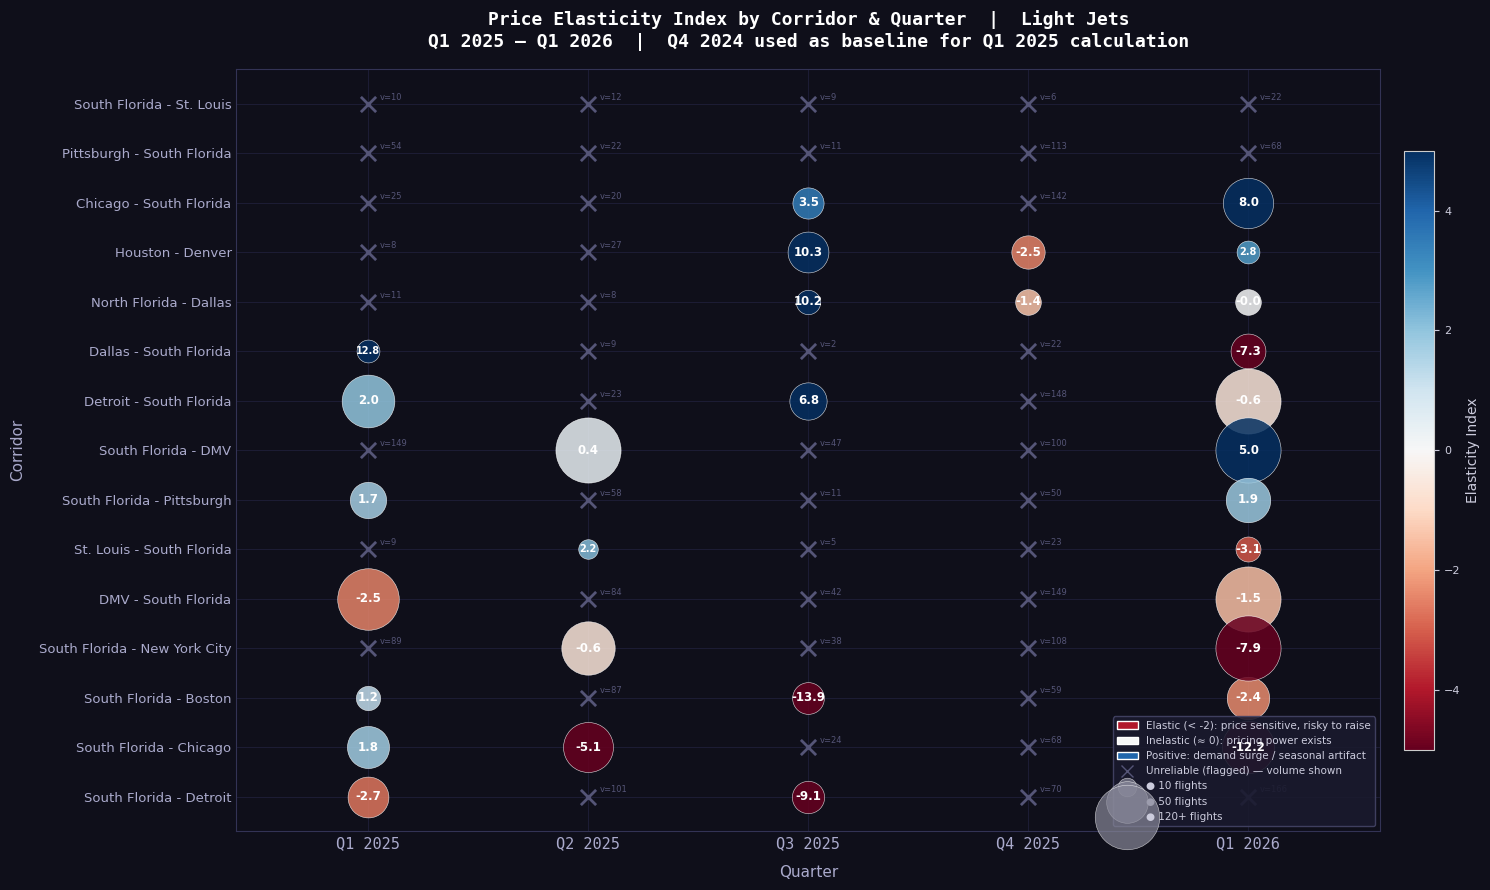

✓ Chart rendered: Light Jets


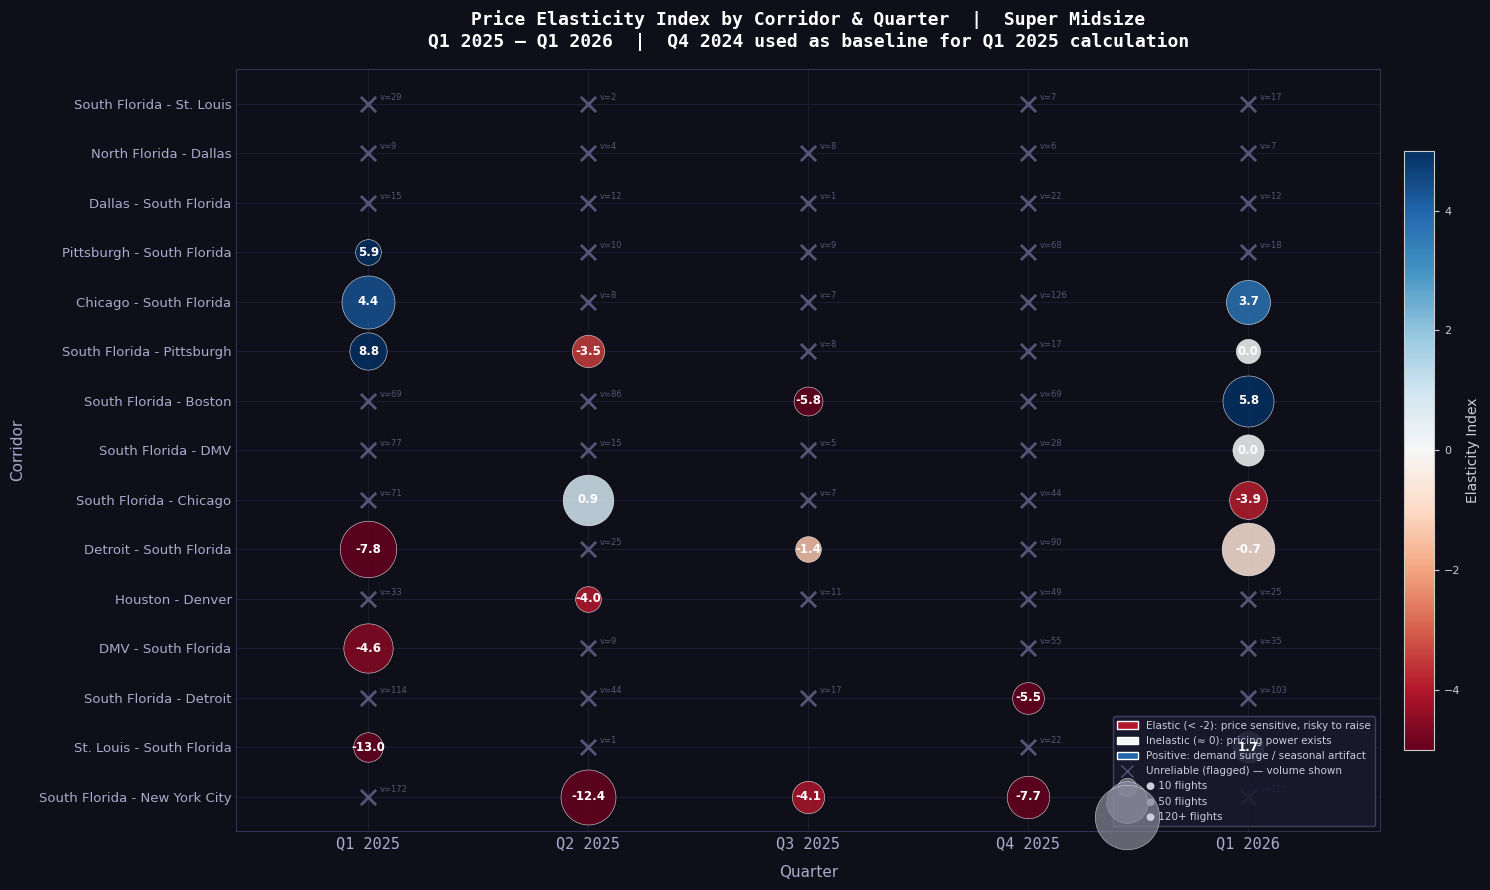

✓ Chart rendered: Super Midsize

RAW OUTPUT TABLE — LIGHT JETS  (paste back for commentary)


,corridor,cabin_group,quarter_label,volume,avg_price,total_rev,vol_pct_chg,price_pct_chg,elasticity,reliability
0,Chicago - South Florida,Light Jets,Q1 2025,25,"19,783","494,586",-74.5%,-3.6%,20.71,extreme_elasticity
2,Chicago - South Florida,Light Jets,Q2 2025,20,"19,617","392,341",-20.0%,-0.8%,23.78,extreme_elasticity
3,Chicago - South Florida,Light Jets,Q3 2025,28,"21,873","612,432",40.0%,11.5%,3.48,OK
5,Chicago - South Florida,Light Jets,Q4 2025,142,"23,129","3,284,364",407.1%,5.7%,70.86,extreme_elasticity
1,Chicago - South Florida,Light Jets,Q1 2026,73,"21,728","1,586,169",-48.6%,-6.1%,8.02,OK
12,DMV - South Florida,Light Jets,Q1 2025,109,"17,349","1,890,989",-28.3%,11.5%,-2.46,OK
14,DMV - South Florida,Light Jets,Q2 2025,84,"17,240","1,448,143",-22.9%,-0.6%,36.60,extreme_elasticity
15,DMV - South Florida,Light Jets,Q3 2025,42,"17,305","726,790",-50.0%,0.4%,NR,no_prior_period
17,DMV - South Florida,Light Jets,Q4 2025,149,"17,897","2,666,672",254.8%,3.4%,74.39,extreme_elasticity
13,DMV - South Florida,Light Jets,Q1 2026,137,"18,854","2,583,052",-8.1%,5.3%,-1.51,OK



RAW OUTPUT TABLE — SUPER MIDSIZE  (paste back for commentary)


,corridor,cabin_group,quarter_label,volume,avg_price,total_rev,vol_pct_chg,price_pct_chg,elasticity,reliability
6,Chicago - South Florida,Super Midsize,Q1 2025,81,"23,998","1,943,860",-24.3%,-5.6%,4.37,OK
8,Chicago - South Florida,Super Midsize,Q2 2025,8,"24,336","194,691",-90.1%,1.4%,-63.97,"low_volume, extreme_elasticity"
9,Chicago - South Florida,Super Midsize,Q3 2025,7,"22,788","159,513",-12.5%,-6.4%,1.96,low_volume
11,Chicago - South Florida,Super Midsize,Q4 2025,126,"31,275","3,940,674",1700.0%,37.2%,45.64,"extreme_price_move, extreme_elasticity"
7,Chicago - South Florida,Super Midsize,Q1 2026,56,"26,548","1,486,713",-55.6%,-15.1%,3.68,OK
18,DMV - South Florida,Super Midsize,Q1 2025,70,"21,039","1,472,703",4.5%,-1.0%,-4.56,OK
20,DMV - South Florida,Super Midsize,Q2 2025,9,"23,461","211,149",-87.1%,11.5%,-7.57,low_volume
22,DMV - South Florida,Super Midsize,Q4 2025,55,"27,505","1,512,779",511.1%,17.2%,29.65,extreme_elasticity
19,DMV - South Florida,Super Midsize,Q1 2026,35,"27,404","959,150",-36.4%,-0.4%,NR,no_prior_period
29,Dallas - South Florida,Super Midsize,Q1 2025,15,"14,872","223,076",-51.6%,2.3%,-22.38,extreme_elasticity



Q4 2024 BASELINE — sanity check (not shown in charts)
Corridors covered : 15
Total data points : 29

Volume by corridor/cabin:


,corridor,cabin_group,volume,avg_price
4,Chicago - South Florida,Light Jets,98,"20,521"
10,Chicago - South Florida,Super Midsize,107,"25,413"
16,DMV - South Florida,Light Jets,152,"15,562"
21,DMV - South Florida,Super Midsize,67,"21,247"
27,Dallas - South Florida,Light Jets,28,"19,545"
33,Dallas - South Florida,Super Midsize,31,"14,536"
39,Detroit - South Florida,Light Jets,91,"19,799"
45,Detroit - South Florida,Super Midsize,115,"23,005"
51,Houston - Denver,Light Jets,31,"18,310"
57,Houston - Denver,Super Midsize,49,"25,438"



RELIABILITY FLAG SUMMARY — display quarters only (Q1 2025–Q1 2026)
reliability
OK                                        53
extreme_elasticity                        51
low_volume                                10
extreme_price_move                        10
low_volume, extreme_elasticity             8
low_volume, extreme_price_move             5
no_prior_period                            5
extreme_price_move, extreme_elasticity     4
no_prior_period, low_volume                1
Name: count, dtype: int64

Clean (OK) data points : 53
Flagged data points    : 94
Total data points      : 147

── Baseline improvement vs prior run ──
Previously OK : 40
Now OK        : 53
Newly unlocked: 13 data points from Q1 2025


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

# ── 1. FULL PIPELINE ──────────────────────────────────────────────────────────

df = df_bookings.copy()

# Flown only
df = df[df['flightStatus'] == 'Flown'].copy()

# Convert to Eastern
df['dep_ET'] = pd.to_datetime(df['flightEstimatedDepartureTime'], utc=True)\
                 .dt.tz_convert('US/Eastern')

# Quarter labels from Eastern time
def assign_quarter(dt):
    return f"Q{dt.quarter} {dt.year}"

df['quarter_label'] = df['dep_ET'].apply(assign_quarter)

# ── Q4 2024 included as baseline — unlocks Q1 2025 elasticity calculations ──
quarter_order     = ['Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026']
display_quarters  = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026']  # shown in chart

df = df[df['quarter_label'].isin(quarter_order)]

# Cabin groups
light_group = ['Light', 'Premium Light']
mid_group   = ['Super Midsize', 'Premium Super-Mid']

def map_cabin(cabin):
    if cabin in light_group:  return 'Light Jets'
    elif cabin in mid_group:  return 'Super Midsize'
    else:                     return None

df['cabin_group'] = df['flightrequestedAircraftCabinName'].map(map_cabin)
df = df[df['cabin_group'].notna()]

# Target corridors
target_corridors = [
    'DMV - South Florida', 'South Florida - DMV', 'South Florida - Chicago',
    'Chicago - South Florida', 'South Florida - New York City', 'South Florida - Detroit',
    'Detroit - South Florida', 'South Florida - Pittsburgh', 'St. Louis - South Florida',
    'North Florida - Dallas', 'Pittsburgh - South Florida', 'South Florida - St. Louis',
    'Dallas - South Florida', 'South Florida - Boston', 'Houston - Denver'
]
df = df[df['corridor'].isin(target_corridors)]

# ── 2. QUARTERLY AGGREGATION ──────────────────────────────────────────────────

quarterly = (
    df.groupby(['corridor', 'cabin_group', 'quarter_label'])
      .agg(
          volume    = ('flightId',   'count'),
          avg_price = ('flightcost', 'mean'),
          total_rev = ('flightcost', 'sum')
      )
      .reset_index()
)

quarterly['quarter_label'] = pd.Categorical(
    quarterly['quarter_label'], categories=quarter_order, ordered=True
)
quarterly = quarterly.sort_values(['corridor', 'cabin_group', 'quarter_label'])

# ── 3. ELASTICITY CALCULATION ─────────────────────────────────────────────────

quarterly['vol_pct_chg']   = quarterly.groupby(['corridor', 'cabin_group'])['volume']\
                                       .pct_change() * 100
quarterly['price_pct_chg'] = quarterly.groupby(['corridor', 'cabin_group'])['avg_price']\
                                       .pct_change() * 100

def safe_elasticity(row):
    if pd.isna(row['price_pct_chg']) or pd.isna(row['vol_pct_chg']):
        return np.nan
    if abs(row['price_pct_chg']) < 0.5:
        return np.nan
    return round(row['vol_pct_chg'] / row['price_pct_chg'], 3)

quarterly['elasticity'] = quarterly.apply(safe_elasticity, axis=1)

# ── 4. RELIABILITY FLAGS ──────────────────────────────────────────────────────

MIN_VOLUME         = 10
MAX_PRICE_CHG      = 20.0
MAX_ABS_ELASTICITY = 15.0

def reliability_flag(row):
    flags = []
    if pd.isna(row['elasticity']):
        flags.append('no_prior_period')
    if row['volume'] < MIN_VOLUME:
        flags.append('low_volume')
    if not pd.isna(row.get('price_pct_chg')) \
       and abs(row['price_pct_chg']) > MAX_PRICE_CHG:
        flags.append('extreme_price_move')
    if not pd.isna(row.get('elasticity')) \
       and abs(row['elasticity']) > MAX_ABS_ELASTICITY:
        flags.append('extreme_elasticity')
    return ', '.join(flags) if flags else 'OK'

quarterly['reliability'] = quarterly.apply(reliability_flag, axis=1)
quarterly['is_reliable']  = quarterly['reliability'] == 'OK'

# ── 5. SPLIT: Q4 2024 baseline rows vs display rows ──────────────────────────
# Q4 2024 was only loaded to enable Q1 2025 elasticity calc — exclude from charts/tables

quarterly_display = quarterly[quarterly['quarter_label'].isin(display_quarters)].copy()
quarterly_display['quarter_label'] = pd.Categorical(
    quarterly_display['quarter_label'], categories=display_quarters, ordered=True
)

# ── 6. BUBBLE CHART FUNCTION ──────────────────────────────────────────────────

def plot_elasticity_bubbles(cabin_name):

    data = quarterly_display[quarterly_display['cabin_group'] == cabin_name].copy()

    # Sort corridors by mean reliable elasticity (most elastic at top)
    corridors_sorted = (
        data[data['is_reliable']]
        .groupby('corridor')['elasticity']
        .mean()
        .sort_values()
        .index.tolist()
    )
    for c in data['corridor'].unique():
        if c not in corridors_sorted:
            corridors_sorted.append(c)

    corridor_pos = {c: i for i, c in enumerate(corridors_sorted)}
    quarter_pos  = {q: i for i, q in enumerate(display_quarters)}

    fig, ax = plt.subplots(figsize=(15, 9))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    norm  = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
    cmap  = plt.get_cmap('RdBu')
    BUBBLE_SCALE = 18

    for _, row in data.iterrows():
        x   = quarter_pos[row['quarter_label']]
        y   = corridor_pos[row['corridor']]
        vol = row['volume']

        if not row['is_reliable']:
            ax.scatter(x, y, marker='x', s=120, color='#555577',
                       linewidths=2, zorder=5)
            ax.annotate(f"v={int(vol)}", (x, y),
                        textcoords='offset points', xytext=(8, 3),
                        fontsize=6, color='#555577')
        else:
            elast = row['elasticity']
            color = cmap(norm(np.clip(elast, -5, 5)))
            size  = max(40, min(vol * BUBBLE_SCALE, 2200))

            ax.scatter(x, y, s=size, color=color, alpha=0.85,
                       edgecolors='white', linewidths=0.4, zorder=5)

            fontsize = 7 if size < 300 else 8.5
            ax.annotate(f"{elast:.1f}", (x, y),
                        ha='center', va='center',
                        fontsize=fontsize, color='white',
                        fontweight='bold', zorder=6)

    # Axes styling
    ax.set_xticks(range(len(display_quarters)))
    ax.set_xticklabels(display_quarters, fontsize=11, color='#ccccdd',
                       fontfamily='monospace')
    ax.set_yticks(range(len(corridors_sorted)))
    ax.set_yticklabels(corridors_sorted, fontsize=9.5, color='#ccccdd')
    ax.set_xlim(-0.6, len(display_quarters) - 0.4)
    ax.set_ylim(-0.7, len(corridors_sorted) - 0.3)

    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')
    ax.grid(True, color='#222240', linewidth=0.5, zorder=0)
    ax.tick_params(colors='#aaaacc', length=0)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                        fraction=0.025, pad=0.02)
    cbar.set_label('Elasticity Index', color='#ccccdd', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='#ccccdd')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccccdd', fontsize=8)
    cbar.ax.set_facecolor('#0f0f1a')

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor=cmap(norm(-4)),
                       label='Elastic (< -2): price sensitive, risky to raise'),
        mpatches.Patch(facecolor=cmap(norm(0)),
                       label='Inelastic (≈ 0): pricing power exists'),
        mpatches.Patch(facecolor=cmap(norm(4)),
                       label='Positive: demand surge / seasonal artifact'),
        plt.Line2D([0],[0], marker='x', color='#555577', linestyle='None',
                   markersize=8, label='Unreliable (flagged) — volume shown'),
    ]
    size_legend = [
        plt.scatter([],[], s=max(40, min(v*BUBBLE_SCALE,2200)),
                    color='#888899', alpha=0.7, edgecolors='white',
                    linewidths=0.4, label=f'● {l}')
        for v, l in [(10,'10 flights'),(50,'50 flights'),(120,'120+ flights')]
    ]
    ax.legend(handles=legend_elements + size_legend,
              loc='lower right', fontsize=7.5,
              facecolor='#1a1a2e', edgecolor='#444466',
              labelcolor='#ccccdd', framealpha=0.9)

    ax.set_title(
        f'Price Elasticity Index by Corridor & Quarter  |  {cabin_name}\n'
        f'Q1 2025 – Q1 2026  |  Q4 2024 used as baseline for Q1 2025 calculation',
        color='white', fontsize=13, fontweight='bold',
        fontfamily='monospace', pad=16
    )
    ax.set_xlabel('Quarter', color='#aaaacc', fontsize=11, labelpad=10)
    ax.set_ylabel('Corridor', color='#aaaacc', fontsize=11, labelpad=10)

    plt.tight_layout()
    plt.show()
    print(f"✓ Chart rendered: {cabin_name}")

# ── 7. RENDER BOTH CHARTS ─────────────────────────────────────────────────────

plot_elasticity_bubbles('Light Jets')
plot_elasticity_bubbles('Super Midsize')

# ── 8. RAW OUTPUT TABLES ──────────────────────────────────────────────────────

output_cols = [
    'corridor', 'cabin_group', 'quarter_label',
    'volume', 'avg_price', 'total_rev',
    'vol_pct_chg', 'price_pct_chg', 'elasticity', 'reliability'
]

def style_table(df_in):
    return (
        df_in.style
        .format({
            'avg_price':     '{:,.0f}',
            'total_rev':     '{:,.0f}',
            'vol_pct_chg':   lambda x: f'{x:.1f}%' if pd.notna(x) else 'NR',
            'price_pct_chg': lambda x: f'{x:.1f}%' if pd.notna(x) else 'NR',
            'elasticity':    lambda x: f'{x:.2f}'  if pd.notna(x) else 'NR'
        })
        .applymap(
            lambda v: 'background-color: #3d0000; color: white'
                      if isinstance(v, float) and pd.notna(v) and v < -2
                      else ('background-color: #003d1a; color: white'
                            if isinstance(v, float) and pd.notna(v) and -0.5 <= v <= 0.5
                            else ''),
            subset=['elasticity']
        )
    )

for cabin in ['Light Jets', 'Super Midsize']:
    print("\n" + "="*90)
    print(f"RAW OUTPUT TABLE — {cabin.upper()}  (paste back for commentary)")
    print("="*90)
    display(
        style_table(
            quarterly_display[quarterly_display['cabin_group'] == cabin][output_cols]
            .sort_values(['corridor', 'quarter_label'])
        )
    )

# ── 9. Q4 2024 BASELINE SUMMARY (sanity check) ───────────────────────────────

q4_2024 = quarterly[quarterly['quarter_label'] == 'Q4 2024'].copy()
print("\n" + "="*70)
print("Q4 2024 BASELINE — sanity check (not shown in charts)")
print("="*70)
print(f"Corridors covered : {q4_2024['corridor'].nunique()}")
print(f"Total data points : {len(q4_2024)}")
print(f"\nVolume by corridor/cabin:")
display(
    q4_2024[['corridor','cabin_group','volume','avg_price']]
    .sort_values(['corridor','cabin_group'])
    .style.format({'avg_price': '{:,.0f}'})
)

# ── 10. RELIABILITY SUMMARY ───────────────────────────────────────────────────

print("\n" + "="*70)
print("RELIABILITY FLAG SUMMARY — display quarters only (Q1 2025–Q1 2026)")
print("="*70)
print(quarterly_display['reliability'].value_counts())
print(f"\nClean (OK) data points : {(quarterly_display['reliability']=='OK').sum()}")
print(f"Flagged data points    : {(quarterly_display['reliability']!='OK').sum()}")
print(f"Total data points      : {len(quarterly_display)}")

# ── 11. IMPROVEMENT TRACKER ───────────────────────────────────────────────────

prev_ok = 40   # from prior run without Q4 2024 baseline
new_ok  = (quarterly_display['reliability'] == 'OK').sum()
unlocked = new_ok - prev_ok

print(f"\n── Baseline improvement vs prior run ──")
print(f"Previously OK : {prev_ok}")
print(f"Now OK        : {new_ok}")
print(f"Newly unlocked: {unlocked} data points from Q1 2025")

# va

In [19]:
df .head()

,flightId,atlasreservationid,flightStatus,legOrder,flightoriginAirportId,flightoriginAirport,flightoriginAirportName,flightoriginAirportCity,flightoriginAirportState,flightoriginAirportCountry,...,flightET,res_id_clean,YearMonth,Quarter,DayOfWeek,Month,IsWeekend,dep_ET,quarter_label,cabin_group
6919,1219567,801922,Flown,2,1026,KBCT,Boca Raton,Boca Raton,FL,US,...,2025-01-05 05:30:00-05:00,801922,2025-01,2025Q1,6,January,Weekend (Fri-Sun),2025-01-05 05:30:00-05:00,Q1 2025,Super Midsize
7823,1223753,804659,Flown,1,340,KCLE,Cleveland Hopkins International,Cleveland,OH,US,...,2024-12-22 07:00:00-05:00,804659,2024-12,2024Q4,6,December,Weekend (Fri-Sun),2024-12-22 07:00:00-05:00,Q4 2024,Light Jets
7824,1223754,804659,Flown,2,2140,KMKY,Marco Island Executive,Marco Island,FL,US,...,2024-12-27 06:00:00-05:00,804659,2024-12,2024Q4,4,December,Weekend (Fri-Sun),2024-12-27 06:00:00-05:00,Q4 2024,Light Jets
7912,1224217,804962,Flown,2,1910,KMTH,Florida Keys Marathon,Marathon,FL,US,...,2024-10-04 07:30:00-04:00,804962,2024-10,2024Q4,4,October,Weekend (Fri-Sun),2024-10-04 07:30:00-04:00,Q4 2024,Light Jets
7996,1224596,805214,Flown,1,548,KROC,Frederick Douglass Greater Rochester Internati...,Rochester,NY,US,...,2024-12-25 12:00:00-05:00,805214,2024-12,2024Q4,2,December,Weekday (Mon-Thu),2024-12-25 12:00:00-05:00,Q4 2024,Super Midsize


In [34]:
Nyc_South_Florida  = df[df['corridor']=='South Florida - New York City']

In [35]:
Nyc_South_Florida['reservationCreateDate'] = pd.to_datetime(Nyc_South_Florida['reservationCreateDate'],utc=True).dt.to_period('M')

In [36]:
Nyc_South_Florida.groupby('reservationCreateDate')['flightId'].count()

reservationCreateDate
2024-06     8
2024-07     3
2024-08     7
2024-09    11
2024-10    66
2024-11    48
2024-12    57
2025-01    83
2025-02    55
2025-03    81
2025-04    74
2025-05    46
2025-06    20
2025-07    24
2025-08    38
2025-09    41
2025-10    64
2025-11    79
2025-12    40
2026-01    96
2026-02    63
2026-03    27
Freq: M, Name: flightId, dtype: int64